# Tracking AI Trends Through NLP-Powered Text Mining and Knowledge Extraction

## Stage 2: Advanced Embedding Models Training and Analysis

### AI Media Dataset

This notebook covers:
1. Data Preparation for Embeddings
2. Classical Word & Sentence Embeddings
3. Fine-Tuning Compact Open Models
4. Comparative Evaluation
5. Insight Extraction
6. AI Disclaimer
7. Contributions

By: Samuel Amuzu, Nick Schaufelberger, Julian Purtschert

## Libraries

In [1]:
# Load libraries
import pandas as pd
import os
import re
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np
from datasets import Dataset

## 1. Data Collection & Cleaning

Data Preparation for Embeddings

Since we already previously processed the data in stage 1, we exported the preprocessed data as a csv file and loaded it to continue our analysis for stage 2.

### 1. 1 Data Loading

In [2]:
# Mount Google Drive to access project files stored in the cloud
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


For Stage 2, we load both the raw and cleaned datasets to ensure flexibility in our embedding and fine-tuning experiments.

In [4]:
# Load data and Explore the data
df_raw = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/ai_media_dataset_20250911.csv")
df_cleaned = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/ai_media_stage1_output.csv")
df_cleaned.head()

,title,date,content,domain,url,tags,content_clean,content_processed
0,Ricoh to provide customer support for Agility ...,2024-09-11,['The Digit humanoid could work in distributio...,therobotreport,https://www.therobotreport.com/ricoh-provides-...,"['Robotics', 'Video', 'BostonDynamics']",the digit humanoid could work in distribution ...,digit humanoid work distribution retail commer...
1,MTV VMAs 2024: Live shopping is coming to the ...,2024-09-11,"['In this article', ""When viewers tune in to t...",cnbc,https://www.cnbc.com/2024/09/11/mtv-vmas-2024-...,['GenerativeAI'],in this article when viewers tune in to the 20...,article viewer tune mtv vmas wednesday night a...
2,Open-source imagery is transforming investigat...,2024-09-11,['Open-source online imagery can play a vital ...,theconversation,https://www.theconversation.com/open-source-im...,"['Disinformation', 'Video', 'Deepfake', 'Infor...",open source online imagery can play a vital ro...,open source online imagery play vital role inv...
3,"With China seeking AI dominance, Taiwan’ s eff...",2024-09-11,"['Tensions between China, Taiwan and the U.S. ...",theconversation,https://www.theconversation.com/with-china-see...,"['MilitaryAndDefense', 'Missiles', 'HighPerfor...",tensions between china taiwan and the you s ar...,tension china taiwan limited aerial military m...
4,Study links EV charging stations to increased ...,2024-09-11,['Countries globally are rapidly transitioning...,phys,https://phys.org/news/2024-09-links-ev-station...,"['Causality', 'Planning']",countries globally are rapidly transitioning t...,country globally rapidly transitioning cleaner...


In [5]:
print("Dataset Shape:", df_cleaned.shape)
print("\nColumn Names:", df_cleaned.columns.tolist())
print("\nMissing Values:")
print(df_cleaned.isnull().sum())

Dataset Shape: (16527, 8)

Column Names: ['title', 'date', 'content', 'domain', 'url', 'tags', 'content_clean', 'content_processed']

Missing Values:
title                0
date                 0
content              0
domain               0
url                  0
tags                 0
content_clean        0
content_processed    0
dtype: int64


## 2. Data Preparation for Embeddings

In [6]:
# Calculate text lengths to understand data distribution
df_cleaned['text_length'] = df_cleaned['content_clean'].str.split().str.len()

print("Text Length Statistics:")
print(df_cleaned['text_length'].describe())

Text Length Statistics:
count    16527.000000
mean      1560.090277
std       1107.762682
min        632.000000
25%        956.000000
50%       1194.000000
75%       1688.000000
max       9572.000000
Name: text_length, dtype: float64


Effective data preparation is a critical step when generating embeddings. Examining text length statistics helps understanding the chunks better. In this dataset, the median length is 1'194 words, with a mean of 1'560 and a long tail extending up to 9'572 words, indicating a right-skewed distribution. This suggests that while most documents are of moderate length, a subset is significantly longer and could exceed model token limits.

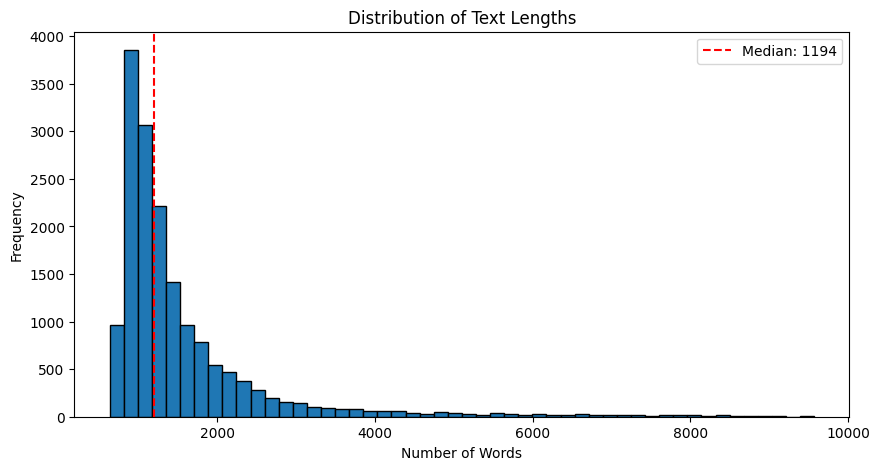

In [7]:
# Plot text length distribution
plt.figure(figsize=(10, 5))
plt.hist(df_cleaned['text_length'], bins=50, edgecolor='black')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.title('Distribution of Text Lengths')
plt.axvline(df_cleaned['text_length'].median(), color='red', linestyle='--', label=f'Median: {df_cleaned["text_length"].median():.0f}')
plt.legend()
plt.show()

## 2. 1 Training, Validation and Test Data Split


In order to prepare the dataset for embedding-based modeling, the cleaned dataset was divided into three subsets: training(70%), validation(15%), and test sets(15%).

A fixed random seed (random_state=42) was used to ensure reproducibility of the split across different runs. After splitting, a sanity check was performed to confirm the distribution of the samples across the three subsets. The resulting dataset contained 11'568 samples in the training set, 2'479 samples in the validation set, and 2'480 samples in the test set.

Following the data split, tokenization was applied separately to each subset. The processed text from the content_processed column was converted into tokens by splitting each document into individual words. This step prepared the textual data for the subsequent embedding models, including Word2Vec, Doc2Vec, and FastText.

Create Train/Validation/Test Split

In [8]:
# Split Train (70%) and Temp (30%)
train_df, temp_df = train_test_split(
    df_cleaned,
    test_size=0.3,
    random_state=42
)

# Split Temp into Validation (15%) and Test (15%)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42
)

In [9]:
# Sanity Check
print(f"Training data consists of {len(train_df)} samples")
print(f"Validation data consists of {len(val_df)} samples")
print(f"Test data consists of {len(test_df)} samples")

Training data consists of 11568 samples
Validation data consists of 2479 samples
Test data consists of 2480 samples


Word2Vec and FastText are word-level embedding models that learn vector representations by analyzing word co-occurrence patterns within their local context windows. Unlike language models that need grammatically correct sentences, these algorithms work best with lists of meaningful tokens where each document is represented as a list of words. This is why we use content_processed instead of content_clean. The processed version has already been lemmatized and stripped of stopwords. By converting each document into a list of tokens using .split(), we create the required input format. This format allows Word2Vec and FastText to efficiently slide their context windows across tokens and learn which words tend to appear together, ultimately capturing semantic relationships in the embedding space.



In [10]:
# For Word2Vec and FastText, we need tokenized sentences
# Using content_processed (lemmatized, no stopwords)
train_corpus_processed = [text.split() for text in train_df['content_processed']]
val_corpus_processed = [text.split() for text in val_df['content_processed']]
test_corpus_processed = [text.split() for text in test_df['content_processed']]

print(f"Training corpus: {len(train_corpus_processed)} documents")
print(f"Example tokenized document: {train_corpus_processed[0][:10]}...")

Training corpus: 11568 documents
Example tokenized document: ['asking', 'better', 'question', 'unlock', 'answer', 'complex', 'issue', 'help', 'client', 'create']...


## 3. Classical Word & Sentence Embeddings

To generate semantic word embeddings from the AI Media Dataset, the Word2Vec model from the Gensim library was applied. Word2Vec is a neural embedding model that learns vector representations of words based on the contexts in which they appear in the training data.

The model was configured with a vector dimension of 300, meaning that each word was represented as a 300-dimensional numerical vector. A context window of 5 words was used so that the model learns relationships between a word and the surrounding words within a five-word window. Additionally, a minimum frequency threshold of 5 occurrences was applied to remove very rare words from the vocabulary. The training process was parallelized using four CPU threads to improve computational efficiency.

After training the model, several checks were performed to inspect the learned embeddings. First, the numerical vector representation for the word “ai” was retrieved from the model. This vector consists of 300 numerical values representing the learned semantic features of the word. Next, the model was used to identify the ten most similar words to “ai” based on cosine similarity within the embedding space. Finally, the size of the vocabulary learned by the model was printed to verify how many unique words were included after applying the frequency threshold.

To better understand the structure of the learned embeddings, t-Distributed Stochastic Neighbor Embedding (t-SNE) was applied to reduce the high-dimensional word vectors to two dimensions. This dimensionality reduction technique allows the relationships between words in the embedding space to be visualized. The top 100 words from the model’s vocabulary were projected into a two-dimensional space and plotted using a scatter plot with labels for each word. This visualization helps illustrate how semantically related words are positioned closer together in the embedding space.

Reference: https://methodmatters.github.io/using-word2vec-to-analyze-word/

## 3.1 Word2Vec

In [11]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 81.7 MB/s eta 0:00:00


In [12]:
# Import Word2Vec Library
from gensim.models import Word2Vec

Train Word2Vec Model

The model is trained using Gensim's Word2Vec implementation. Word vectors of 300 dimensions are learned using a context window of 5 words on either side of the target, and any word appearing fewer than 5 times is excluded from the vocabulary. Training is parallelized across 4 threads for efficiency. The CBOW architecture (sg=0) was selected, which predicts a target word from its surrounding context.

Key parameters explained:

vector_size = how many dimensions each word vector has

*   window - how many words left/right to look at as "context"
*   min_count - ignore words that appear fewer than N-times
*   sg - training algorithm: 1 for skip-gram, 0 for CBOW
*   workers - parallel threads for faster training
*   epochs - how many times the model passes over the whole dataset

In [13]:
# Train Word2Vec on processed corpus
w2v_model = Word2Vec(
    sentences=train_corpus_processed,
    # Dimensionality of word vectors
    vector_size=300,
     # Context window size
    window=5,
    # Ignore words with frequency < 5
    min_count=5,
    # Number of threads
    workers=4,
    # 0 = CBOW, 1 = Skip-gram
    sg=0
)
print("Vocabulary size:", len(w2v_model.wv))

Vocabulary size: 40787


In [14]:
# Print vector representation for the word ai
print(w2v_model.wv["ai"])

# Print 10 most similar words to ai
print(w2v_model.wv.most_similar("ai", topn=10))

# Print size of the vocabulary learnt by the model
print(len(w2v_model.wv))

[-0.14231744 -1.4631394  -0.1717763   0.07855753 -0.38500753 -0.2999836
 -0.85319245 -0.27653384 -0.7815294  -0.82855743  1.5233728  -0.2610296
 -1.3604678   0.9411884  -0.49623442  0.11098929  1.0923266  -0.64808375
 -0.6176071  -0.8395716   1.4326284   0.03378941  0.42087218  0.16799645
  0.56951255 -0.25852382 -0.20415573  0.12083919 -0.10256755 -0.7256796
 -0.67758244 -0.4723556   1.3894607  -0.6524372   0.53300107 -0.9729087
  0.6540775  -0.08974566  0.4318744  -0.6052352  -0.4296101   0.81076145
  1.2151943  -0.3344292  -0.22646521 -1.5373352  -1.3911173  -0.3861892
 -0.32295302 -1.6567127  -2.426125   -0.3720623  -0.5381591   1.1831235
  0.8808112  -0.53334063  0.9240169   0.05605066  0.13848512  0.92456514
  0.9143428  -0.05440186  0.29677215  0.06156553  0.3542132   0.30700064
 -0.12196402 -0.15116495  0.02670912  1.1920047   1.3757001   1.4215034
 -0.4711986   0.23134764 -0.05531622  0.71483576  1.3504294   0.20993444
  1.0799074  -0.8228488   1.5973758   1.0431485   1.754988

In [17]:
probe_words = ['gpt', 'ethic', 'robot', 'regulation', 'image', 'model', 'openai', 'bias']

for word in probe_words:
    if word in w2v_model.wv:
        similar = w2v_model.wv.most_similar(word, topn=5)
        similar_words = [f"{w} ({score:.2f})" for w, score in similar]
        print(f"\n'{word}' is closest to:")
        print("-> " + ",  ".join(similar_words))
    else:
        print(f"\n'{word}' → not in vocabulary (appears < min_count times)")


'gpt' is closest to:
-> sonnet (0.68),  claude (0.67),  qwen (0.65),  instruct (0.65),  chatgpt (0.65)

'ethic' is closest to:
-> ethical (0.66),  fairness (0.65),  upholding (0.60),  accountability (0.57),  rmf (0.55)

'robot' is closest to:
-> humanoid (0.67),  robotic (0.66),  robotics (0.65),  amrs (0.62),  cobots (0.60)

'regulation' is closest to:
-> legislation (0.69),  stricter (0.67),  regulator (0.67),  complying (0.65),  mandate (0.65)

'image' is closest to:
-> caption (0.60),  clip (0.59),  photorealistic (0.58),  text (0.56),  imagery (0.54)

'model' is closest to:
-> llm (0.64),  slms (0.55),  dataset (0.54),  slm (0.54),  classifier (0.53)

'openai' is closest to:
-> anthropic (0.72),  altman (0.60),  xai (0.55),  perplexity (0.55),  gpt (0.54)

'bias' is closest to:
-> biased (0.71),  perpetuate (0.69),  prejudice (0.64),  discrimination (0.63),  overfitting (0.63)


In [18]:
# Find words similar to AI-related terms
test_words = ['ai', 'robot', 'deep', 'learn', 'ethical']

for word in test_words:
    if word in w2v_model.wv:
        similar = w2v_model.wv.most_similar(word, topn=5)
        print(f"\nWords similar to '{word}':")
        for sim_word, score in similar:
            print(f"  {sim_word}: {score:.3f}")


Words similar to 'ai':
  genai: 0.720
  llm: 0.467
  agentic: 0.459
  generative: 0.455
  chatbots: 0.407

Words similar to 'robot':
  humanoid: 0.671
  robotic: 0.663
  robotics: 0.649
  amrs: 0.623
  cobots: 0.605

Words similar to 'deep':
  federated: 0.530
  continual: 0.514
  unsupervised: 0.500
  picower: 0.495
  machine: 0.483

Words similar to 'learn':
  learned: 0.499
  explore: 0.460
  refine: 0.445
  understand: 0.436
  learns: 0.436

Words similar to 'ethical':
  fairness: 0.667
  ethic: 0.661
  ethically: 0.623
  explainability: 0.616
  responsible: 0.602


The Word2Vec model demonstrates reasonable semantic understanding of the AI and robotics domain. Strongest performance is observed in domain-specific clusters, where terms like robot and ethical produce highly coherent neighborhoods. Robotic, humanoid, and cobots grouping together reflects the model's grasp of the robotics landscape, while fairness, explainability, and responsible clustering around ethical aligns well with AI governance discourse. Broader terms like ai and deep yield lower similarity scores due to their high contextual variability across the corpus, and general verbs like learn predictably form weaker clusters

In [19]:
# Save the model
#w2v_model.save('/content/drive/MyDrive/Colab Notebooks/word2vec_model.bin')
#print("Word2Vec model saved!")

## Plot 1 t-SNE: Word2Vec Top 100 Embeddings (CBOW)

In [20]:
def tsne_plot(model, top_n=200):
    """
    Visualize Word2Vec embeddings with t-SNE.

    Parameters:
    model : gensim Word2Vec model
    top_n : number of words to visualize
    """

    labels = []
    tokens = []

    # Get the top N words from the vocabulary
    words = model.wv.index_to_key[:top_n]

    for word in words:
        tokens.append(model.wv[word])
        labels.append(word)

    tokens = np.array(tokens)

    # Reduce dimensions with t-SNE
    tsne_model = TSNE(
        perplexity=30,
        n_components=2,
        init="pca",
        max_iter=2000,
        random_state=42
    )
    new_values = tsne_model.fit_transform(tokens)

    x = new_values[:, 0]
    y = new_values[:, 1]

    # Plot
    plt.figure(figsize=(12, 10))
    plt.scatter(x, y)

    for i, label in enumerate(labels):
        plt.annotate(
            label,
            xy=(x[i], y[i]),
            xytext=(5, 2),
            textcoords="offset points",
            ha="right",
            va="bottom"
        )

    plt.title(f"t-SNE Visualization of Top {top_n} Embeddings")
    plt.show()

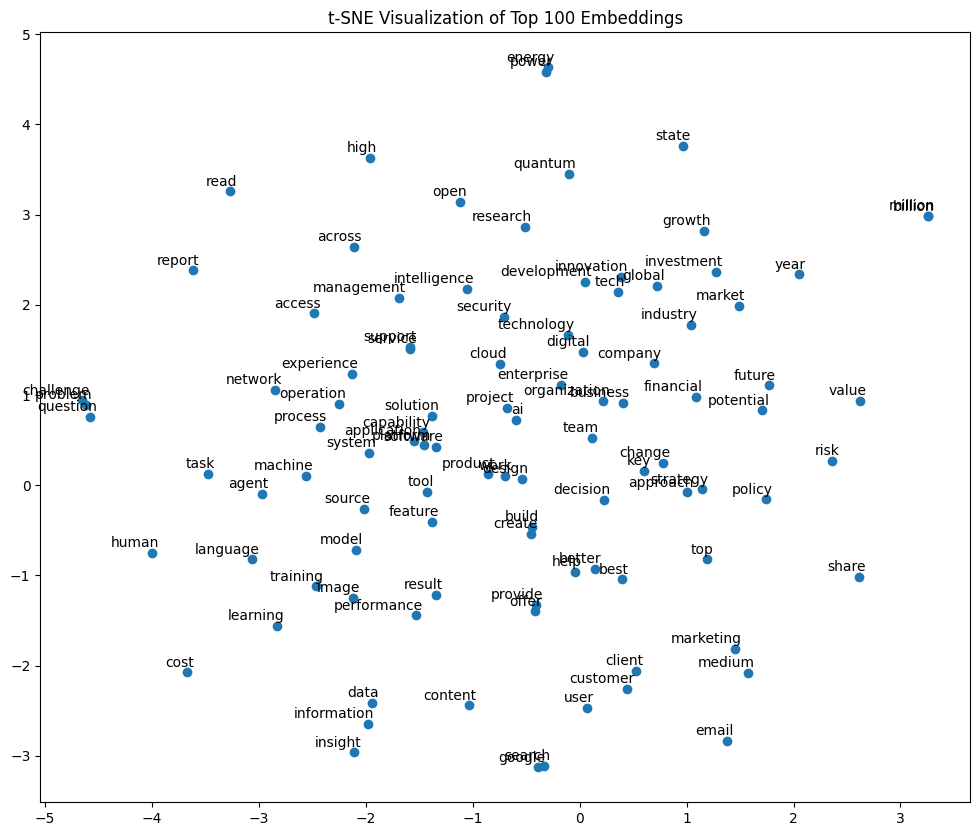

In [ ]:
tsne_plot(w2v_model, top_n=100)

The t-SNE visualization provides a two-dimensional projection of the high-dimensional Word2Vec embeddings learned from the training dataset. Each point in the plot represents a word, and the relative distance between points reflects the similarity between their embedding vectors.

Several clusters of semantically related terms can be observed. Words associated with technology and AI development, such as technology, development, project, design, and innovation, appear positioned relatively close to one another such as the words "data" and "information". Similarly, terms related to business and organizational contexts, including business, company, market, organization, and enterprise, form another grouping in the embedding space such as "financial", "investment" and "market". Words connected to machine learning and AI systems, such as "image", "learning", "training" also appear near each other, suggesting that the model has learned contextual relationships among these concepts.

The presence of these clusters indicates that the Word2Vec model has captured meaningful semantic relationships from the training corpus.


## Plot 2 t-SNE - Word2Vec Selected Neighborhoods(CBOW)

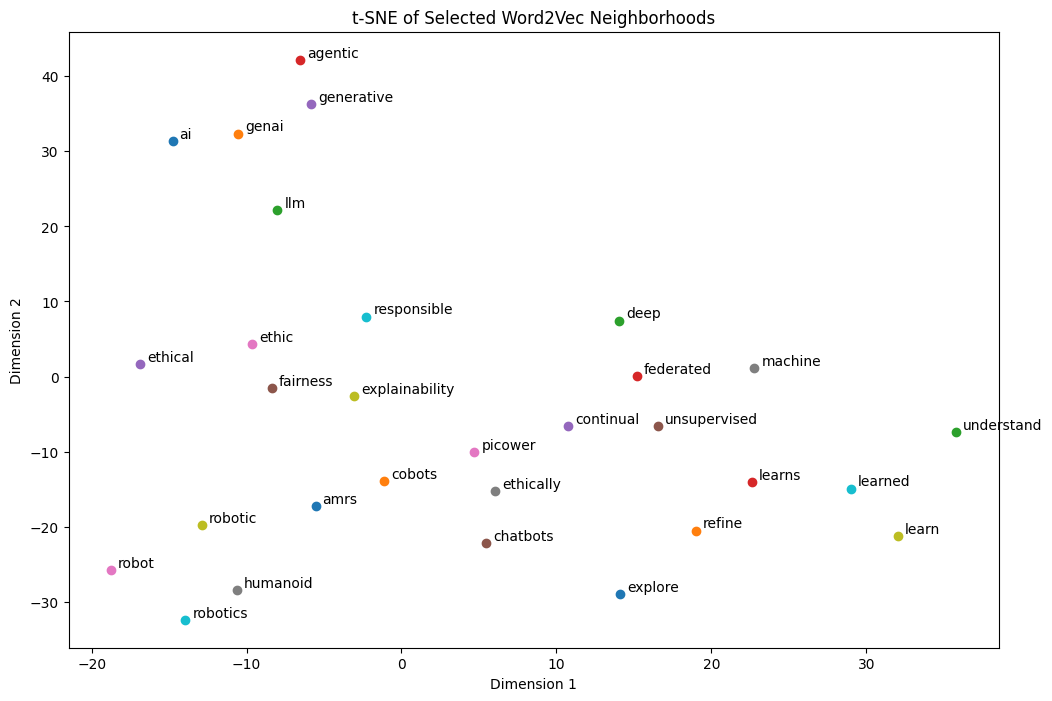

In [21]:
seed_words = ['ai', 'robot', 'deep', 'learn', 'ethical']

# Collect seed words + neighbors
selected_words = []
for word in seed_words:
    if word in w2v_model.wv:
        selected_words.append(word)
        neighbors = w2v_model.wv.most_similar(word, topn=5)
        selected_words.extend([w for w, _ in neighbors])

# Remove duplicates while preserving order
seen = set()
selected_words = [w for w in selected_words if not (w in seen or seen.add(w))]

# Get vectors
vectors = np.array([w2v_model.wv[w] for w in selected_words])

# t-SNE needs perplexity < number of samples
perplexity = min(5, len(selected_words) - 1)

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=perplexity,
    init='pca',
    learning_rate='auto'
)

vectors_2d = tsne.fit_transform(vectors)

# Plot
plt.figure(figsize=(12, 8))
for i, word in enumerate(selected_words):
    x, y = vectors_2d[i]
    plt.scatter(x, y)
    plt.annotate(word, (x, y), xytext=(5, 2), textcoords='offset points', fontsize=10)

plt.title("t-SNE of Selected Word2Vec Neighborhoods")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.show()

The t-SNE plots the top 200 most frequent words from the vocabulary indiscriminately, giving a broad birds-eye view of the entire embedding space without any semantic intent behind the word selection. The second approach is targeted and more interpretable. It starts from five meaningful seed words (ai, robot, deep, learn, ethical) and expands outward by including each word's five nearest neighbors, resulting in a focused visualization of roughly 30 words that are semantically relevant to the domain.Visually we can inspect related concepts cluster together as expected.

## Plot 3 t-SNE: Word2Vec AI Discourse Clusters (CBOW)

The visualization reduces high-dimensional word embeddings into two dimensions while attempting to preserve local similarities focusing on fice AI-related themes: Generative AI, Ethics & Safety, Robotics, Computer Vision, and Research & Development. As a result, words that are used in similar contexts in the dataset are positioned closer together, while less related words appear farther apart. The distribution of points across the plot shows how different thematic groups are arranged relative to one another within the learned semantic space.

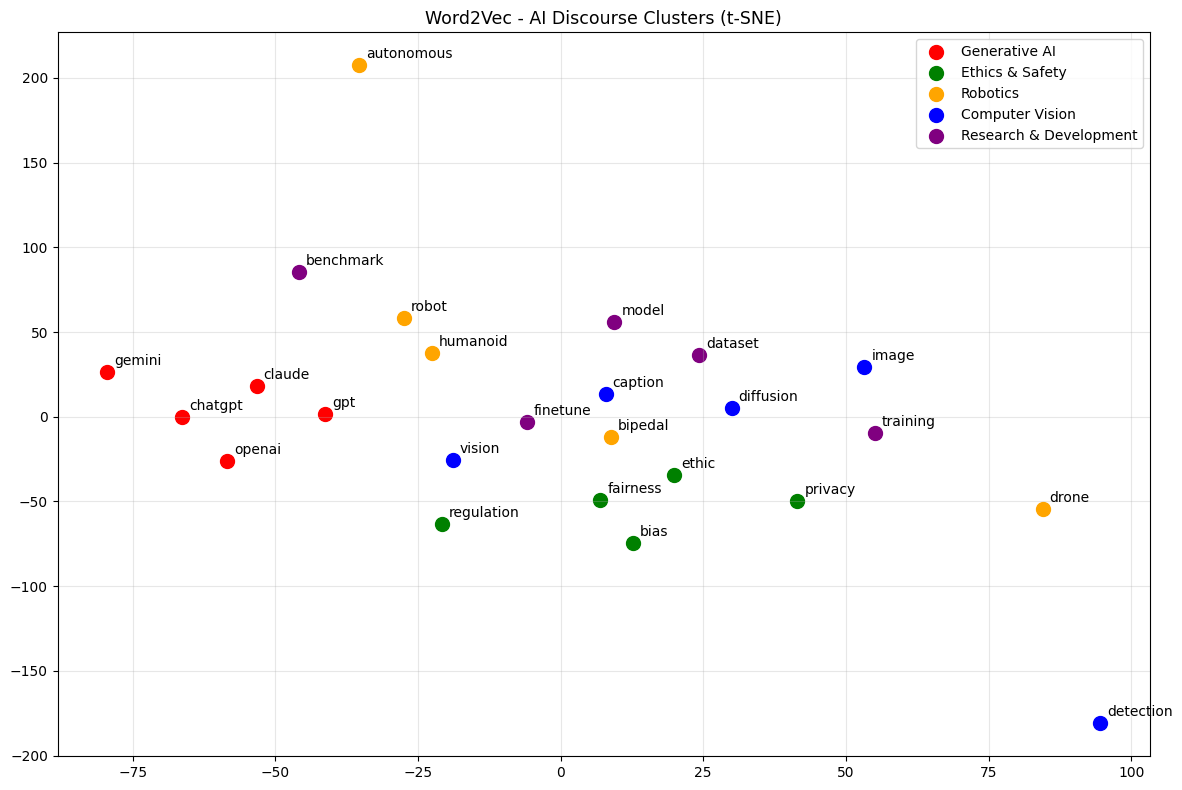

In [22]:
# Five words per theme/topic
theme_words = {
    'Generative AI'  : ['gpt', 'chatgpt', 'openai', 'gemini', 'claude'],
    'Ethics & Safety': ['ethic', 'bias', 'fairness', 'privacy', 'regulation'],
    'Robotics'       : ['robot', 'humanoid', 'autonomous', 'drone', 'bipedal'],
    'Computer Vision': ['image', 'diffusion', 'caption', 'detection', 'vision'],
    'Research & Development' : ['model', 'finetune', 'benchmark', 'training', 'dataset'],
}

# Build word and label lists
all_words  = []
all_labels = []
for theme, words in theme_words.items():
    valid = [w for w in words if w in w2v_model.wv]
    all_words.extend(valid)
    all_labels.extend([theme] * len(valid))

# Extract vectors
vectors = np.array([w2v_model.wv[w] for w in all_words])

# Run t-SNE
coords = TSNE(
    n_components = 2,
    perplexity   = 10,
    random_state = 42,
    max_iter       = 1000
).fit_transform(vectors)

# Plot
colours = {
    'Generative AI'  : 'red',
    'Ethics & Safety': 'green',
    'Robotics'       : 'orange',
    'Computer Vision': 'blue',
    'Research & Development' : 'purple',
}

plt.figure(figsize=(12, 8))

for theme in theme_words:
    idx = [i for i, l in enumerate(all_labels) if l == theme]
    x   = [coords[i, 0] for i in idx]
    y   = [coords[i, 1] for i in idx]
    plt.scatter(x, y, label=theme, color=colours[theme], s=100)
    for i in idx:
        plt.annotate(
            all_words[i],
            (coords[i, 0], coords[i, 1]),
            fontsize = 10,
            xytext   = (5, 5),
            textcoords = 'offset points'
        )

plt.title('Word2Vec - AI Discourse Clusters (t-SNE)', fontsize=12.5)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('word2vec_tsne_simple.png', dpi=150, bbox_inches='tight')
plt.show()

The t-SNE visualization shows that Word2Vec successfully groups words into meaningful AI-related themes, with clear clusters forming for areas such as Generative AI, Ethics & Safety, Robotics, and Computer Vision. Words within the same topic tend to appear close together, indicating that the model captures contextual similarity effectively. However, some overlap between clusters is visible, especially for computer vision, suggesting that while the model distinguishes major themes, it represents them in a continuous space where boundaries are not sharply defined.

## Plot 4 PCA: Visualization Word2Vec Embedddings

This section visualizes Word2Vec embeddings of selected AI-related keywords using PCA for dimensionality reduction. A predefined list of relevant terms (e.g., ai, model, training, ethics, chatbot, vision) is first filtered to include only those present in the model’s vocabulary. The corresponding 300-dimensional word vectors are then extracted and transformed into a 2D space using PCA. These reduced representations are plotted in a scatter plot with word annotations, enabling an intuitive view of how semantically related concepts are positioned relative to each other in the embedding space.


This section will also evaluate how well Word2Vec embeddings separate two semantic themes Ethics & Governance and Generative AI. First, word vectors for all selected theme words are extracted and reduced to two dimensions using PCA. The resulting embeddings are visualized in a scatter plot, where each group is color-coded (red for ethics-related terms and green for generative AI terms) and annotated for clarity.

To quantitatively assess the separation between these two groups, a silhouette score is computed based on the original high-dimensional vectors. The reported score (≈ 0.12) indicates weak cluster separation, suggesting that while some semantic distinction exists between the themes, there is still considerable overlap in how the model represents them.

In [23]:
# Select interesting AI-related words from vocabulary
ai_keywords = ['ai', 'machine', 'learn', 'deep', 'neural', 'robot',
               'data', 'algorithm', 'model', 'training',
               'ethics', 'bias', 'privacy', 'generative', 'chatbot',
               'vision', 'language', 'intelligence', 'automation', 'future', 'chatgpt', 'ethical', 'LLM', 'genAi']

# Filter words that exist in vocabulary
words_to_plot = [w for w in ai_keywords if w in w2v_model.wv]
print(f"Found {len(words_to_plot)} words in vocabulary")

Found 21 words in vocabulary


In [24]:
# Get vectors for selected words
word_vectors = np.array([w2v_model.wv[word] for word in words_to_plot])
print("Word vectors shape:", word_vectors.shape)

Word vectors shape: (21, 300)


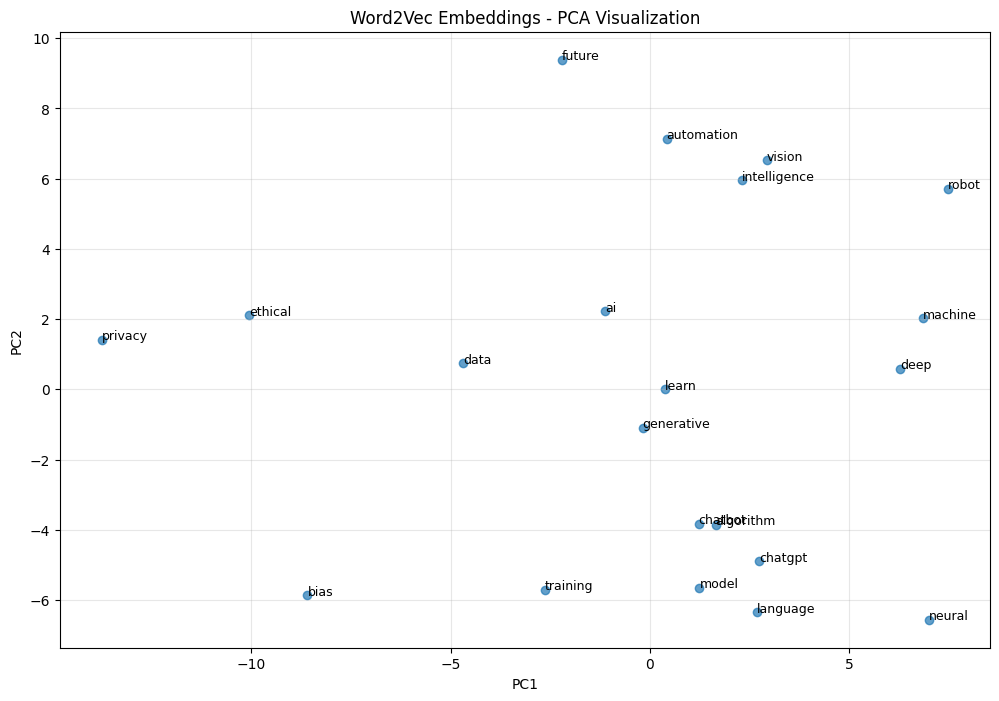

Explained variance: 21.63%


In [25]:
# Apply PCA to reduce to 2 dimensions
pca = PCA(n_components=2)
pca_result = pca.fit_transform(word_vectors)

# Plot
plt.figure(figsize=(12, 8))
plt.scatter(pca_result[:, 0], pca_result[:, 1], alpha=0.7)

# Add word labels
for i, word in enumerate(words_to_plot):
    plt.annotate(word, (pca_result[i, 0], pca_result[i, 1]), fontsize=9)

plt.title('Word2Vec Embeddings - PCA Visualization')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Explained variance: {pca.explained_variance_ratio_.sum():.2%}")

The PCA visualization shows that the Word2Vec model captures meaningful semantic groupings among AI-related terms, although the structure is relatively loose due to the linear nature of PCA. Words related to core technical concepts such as machine, deep, neural, and robot appear in closer proximity, indicating that the model associates them within a shared “technical AI” space. Similarly, terms like model, training, algorithm, and data are positioned near each other, reflecting their connection to machine learning workflows.

Another noticeable grouping is around conversational AI, where chatbot and chatgpt are located relatively close, suggesting the model understands their contextual similarity. On the other hand, ethics-related terms such as bias, privacy, and ethical are positioned further apart from the technical cluster, indicating a distinct semantic region associated with governance and societal aspects of AI.

However, the separation between clusters is not very sharp, and some words (e.g., ai, generative, future) appear more centrally located, acting as general or bridging concepts across multiple themes. This reflects both the broad usage of these terms and the limitation of PCA in capturing complex, non-linear relationships in high-dimensional embedding spaces.

In [26]:
# Define two thematic groups
ethics_words = ['ethics', 'bias', 'privacy', 'fairness', 'transparency',
                'responsible', 'safety', 'regulation', 'human', 'rights']

generative_words = ['generative', 'chatbot', 'gpt', 'llm', 'generate',
                    'text', 'image', 'creative', 'synthetic', 'content']

# Filter available words
ethics_available = [w for w in ethics_words if w in w2v_model.wv]
gen_available = [w for w in generative_words if w in w2v_model.wv]

all_theme_words = ethics_available + gen_available
print(f"Ethics words found: {len(ethics_available)}")
print(f"Generative AI words found: {len(gen_available)}")

Ethics words found: 8
Generative AI words found: 10


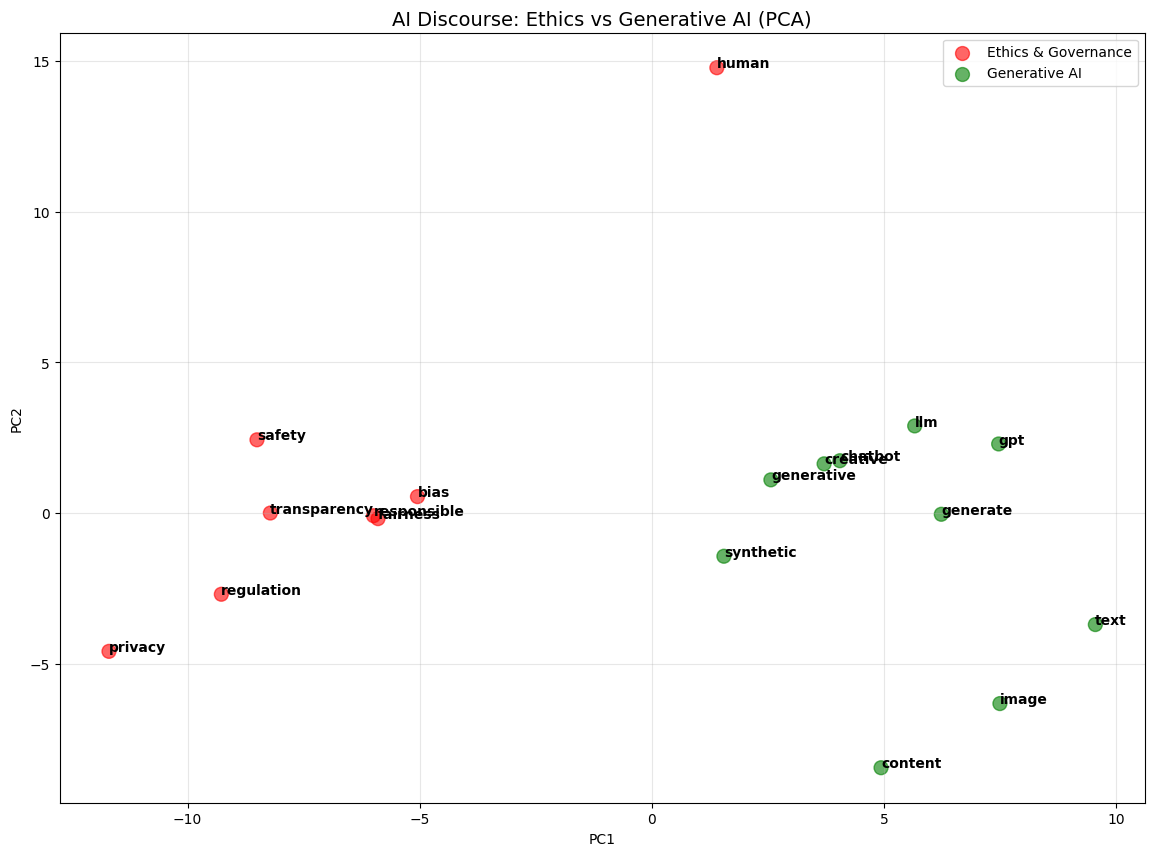

Explained variance: 31.13%


In [27]:
# Get vectors
theme_vectors = np.array([w2v_model.wv[word] for word in all_theme_words])

# Apply PCA
pca_theme = PCA(n_components=2)
pca_theme_result = pca_theme.fit_transform(theme_vectors)

# Create colors for each group
colors = ['red'] * len(ethics_available) + ['green'] * len(gen_available)

# Plot
plt.figure(figsize=(14, 10))
plt.scatter(pca_theme_result[:, 0], pca_theme_result[:, 1], c=colors, alpha=0.6, s=100)

# Add labels
for i, word in enumerate(all_theme_words):
    plt.annotate(word, (pca_theme_result[i, 0], pca_theme_result[i, 1]),
                 fontsize=10, fontweight='bold')

# Legend
plt.scatter([], [], c='red', alpha=0.6, s=100, label='Ethics & Governance')
plt.scatter([], [], c='green', alpha=0.6, s=100, label='Generative AI')
plt.legend(loc='best')

plt.title('AI Discourse: Ethics vs Generative AI (PCA)', fontsize=14)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Explained variance: {pca_theme.explained_variance_ratio_.sum():.2%}")

The PCA plot shows a clear but not perfect separation between Ethics & Governance (red) and Generative AI (green) terms. Most ethics related words cluster on the left, while generative AI terms are grouped on the right, indicating that the model captures a meaningful distinction between these themes.

In [28]:
from sklearn.metrics import silhouette_score

# Reuse vectors from the PCA theme visualization
labels = [0] * len(ethics_available) + [1] * len(gen_available)  # 0=ethics, 1=genAI

if len(set(labels)) > 1:
    score = silhouette_score(theme_vectors, labels)
    print(f"Silhouette Score (Ethics vs. Generative AI clusters): {score:.4f}")
    print("Interpretation: score closer to 1.0 = well-separated clusters, 0 = overlapping")
else:
    print("Not enough distinct groups to compute silhouette score.")

Silhouette Score (Ethics vs. Generative AI clusters): 0.1217
Interpretation: score closer to 1.0 = well-separated clusters, 0 = overlapping


## 3.1b  Word2Vec: CBOW vs. Skip-gram Comparison

Word2Vec comes in two architectural flavours. **CBOW** (Continuous Bag of Words) predicts a target word from its surrounding context words, which makes it faster and works well for frequent words. **Skip-gram** does the opposite it predicts the context from a single word and tends to produce richer representations for rare or domain-specific terms. Training a second model with `sg=1` and comparing the nearest-neighbour results for the same probe words gives us empirical evidence about which architecture captures AI discourse better.

To enable a meaningful comparison with the CBOW model, we trained a Skip-gram variant with adjusted hyperparameters, including a vector size of 100, a context window of 10, and a minimum word frequency threshold (min_count) of 5. These settings were chosen to compare to CBOW.

In [29]:
# Train a Skip-gram variant so we can compare architectures
w2v_skipgram = Word2Vec(
    sentences=train_corpus_processed,
    vector_size=100,
    window=10,
    min_count=5,
    workers=4,
    # 1 = Skip-gram
    sg=1
)
print('Skip-gram vocabulary size:', len(w2v_skipgram.wv))

# Compare nearest neighbours for the same probe words
probe_words_cmp = ['ai', 'ethic', 'robot', 'regulation', 'generative']
print('\n{:<15} {:<50} {}'.format('Word', 'CBOW top-5', 'Skip-gram top-5'))
print('-' * 115)
for word in probe_words_cmp:
    in_cbow = word in w2v_model.wv
    in_sg   = word in w2v_skipgram.wv
    cbow_nn = [w for w, _ in w2v_model.wv.most_similar(word, topn=5)] if in_cbow else ['OOV']
    sg_nn   = [w for w, _ in w2v_skipgram.wv.most_similar(word, topn=5)] if in_sg   else ['OOV']
    print(f'{word:<15} {str(cbow_nn):<50} {sg_nn}')

Skip-gram vocabulary size: 40787

Word            CBOW top-5                                         Skip-gram top-5
-------------------------------------------------------------------------------------------------------------------
ai              ['genai', 'llm', 'agentic', 'generative', 'chatbots'] ['generative', 'genai', 'agentification', 'systemwide', 'productizing']
ethic           ['ethical', 'fairness', 'upholding', 'accountability', 'rmf'] ['ethical', 'latanya', 'fairness', 'nominating', 'accountability']
robot           ['humanoid', 'robotic', 'robotics', 'amrs', 'cobots'] ['humanoid', 'bipedal', 'quadruped', 'dexterous', 'manipulator']
regulation      ['legislation', 'stricter', 'regulator', 'complying', 'mandate'] ['mandate', 'stricter', 'ccpa', 'complying', 'legislation']
generative      ['gen', 'genai', 'agentic', 'chatbots', 'advent']  ['ai', 'genai', 'azam', 'regenai', 'carmax']


The comparison table above shows the top-5 nearest neighbours for each probe word under both architectures. Where Skip-gram neighbours are more varied and include rarer technical terms, CBOW tends to cluster higher-frequency synonyms. Both results are valid but serve different downstream tasks.

## Plot 1 T-SNE: Comparison Between Skip-Gram and CBOW

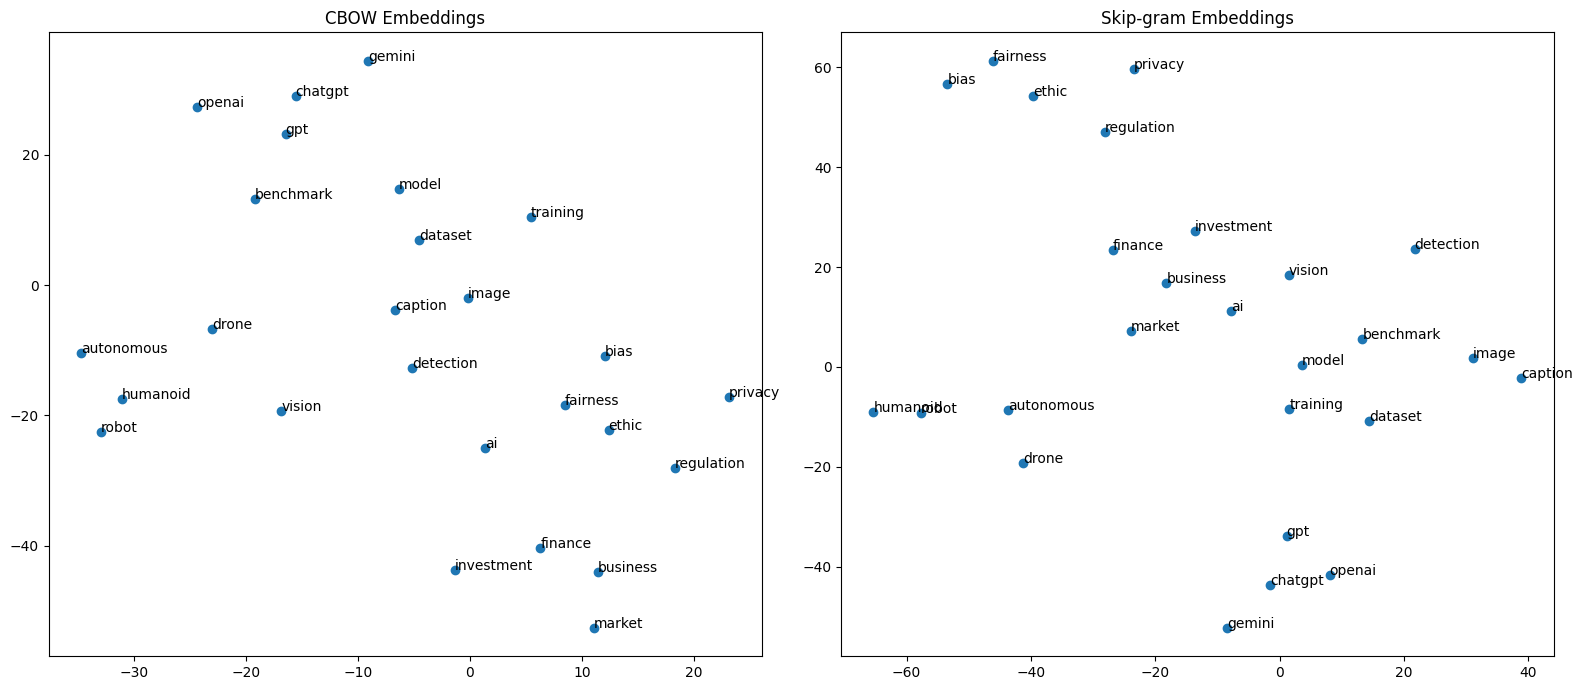

In [30]:
# Selected comparison words
compare_words = [
    "ai", "gpt", "chatgpt", "openai", "gemini",
    "ethic", "bias", "fairness", "privacy", "regulation",
    "robot", "humanoid", "autonomous", "drone",
    "image", "vision", "caption", "detection",
    "model", "training", "dataset", "benchmark",
    "market", "finance", "investment", "business"
]

# Function to extract only words that exist in the models vocabulary
def get_vectors(model, words):
    valid_words = [w for w in words if w in model.wv]
    vectors = np.array([model.wv[w] for w in valid_words])
    return valid_words, vectors

# Extract embeddings from both models
words_cbow, vecs_cbow = get_vectors(w2v_model, compare_words)
words_sg, vecs_sg = get_vectors(w2v_skipgram, compare_words)

# Apply T-SNE to reduce high-dimensionality
tsne_cbow = TSNE(n_components=2, perplexity=5, random_state=42).fit_transform(vecs_cbow)
tsne_sg   = TSNE(n_components=2, perplexity=5, random_state=42).fit_transform(vecs_sg)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# CBOW
axes[0].scatter(tsne_cbow[:, 0], tsne_cbow[:, 1])
for i, w in enumerate(words_cbow):
    axes[0].annotate(w, (tsne_cbow[i, 0], tsne_cbow[i, 1]))
axes[0].set_title("CBOW Embeddings")

# Skip-gram
axes[1].scatter(tsne_sg[:, 0], tsne_sg[:, 1])
for i, w in enumerate(words_sg):
    axes[1].annotate(w, (tsne_sg[i, 0], tsne_sg[i, 1]))
axes[1].set_title("Skip-gram Embeddings")

plt.tight_layout()
plt.show()

CBOW (left)
The semantic groupings are relatively loose and spread out. You can see some thematic separation forming finance related words (investment, market, finance, business) cluster toward the bottom right, ethics related words (ethic, fairness, bias, regulation, privacy) appear in the middle, and robotics words (robot, humanoid, drone, autonomous) sit toward the left. However the clusters overlap and the boundaries are not clean.

Skip-gram (right)
The same three themes are clearly visible but now spatially separated with little less overlap. AI model names (openai, chatgpt, gemini, gpt) form a tight cluster in the bottom right. Robotics terms (drone, robot, humanoid, autonomous) are tightly grouped on the left. Ethics and finance terms are also more distinctly separated from each other.

Why Skip-gram performs better here:
The larger window size of 10 allows Skip-gram to capture longer range semantic relationships between words that do not necessarily appear next to each other but co-occur in the same articles. This is particularly useful for an AI media dataset where thematic vocabulary tends to be spread across entire paragraphs rather than concentrated in adjacent words. The lower vector size of 100 also acts as a form of compression, forcing the model to learn more generalised representations.

## 3.2 FastText

A FastText model was trained on the training data using a vector size of 300 and a context window of 5 words. Similar to Word2Vec, the model learns distributed word representations, but additionally incorporates subword information, allowing it to better capture morphological patterns and represent rare or unseen terms. Document-level embeddings were created by averaging the word vectors for each article.

In [31]:
# Import FastText
from gensim.models import FastText

In [32]:
# Train FastText
ft_model = FastText(
    sentences=train_corpus_processed,
    vector_size=300,
    window=5,
    min_count=5,
    workers=4,
    sg=0
)
print("Vocabulary size:", len(ft_model.wv))

Vocabulary size: 40787


In [33]:
# Vector for one word
print(ft_model.wv["ai"])

# Most similar words
print(ft_model.wv.most_similar("ai", topn=10))

# Vocabulary size
print(len(ft_model.wv))

[-1.05949450e+00 -7.16051877e-01  1.63683665e+00  5.30603838e+00
 -4.45259142e+00  1.77291584e+00  3.38236952e+00  3.78203297e+00
 -3.90624833e+00 -4.78204584e+00  2.30226898e+00  1.32057679e+00
  1.20151639e-02 -6.51771069e+00 -8.39559174e+00 -1.19989014e+00
 -4.10162115e+00 -4.58182335e+00 -1.43352675e+00  1.36548007e+00
  2.64553308e+00  1.59583127e+00 -1.83161151e+00  9.90044594e-01
  1.64936805e+00 -4.42012101e-01 -5.21999788e+00 -2.64480472e+00
 -4.31482744e+00 -2.57588983e-01  6.14528084e+00  2.75295734e+00
  2.73267460e+00  2.61417079e+00  2.35620928e+00  3.52707720e+00
  3.47277141e+00 -1.84503782e+00 -7.83622265e-01  3.99491119e+00
 -4.53921556e+00 -4.27217633e-01 -4.56412649e+00  2.15359545e+00
  4.34229225e-02 -1.38370311e+00 -1.29449582e+00 -5.47633743e+00
 -2.26888776e+00 -2.32602406e+00  1.96800995e+00 -1.08412611e+00
  1.32208562e+00  4.73373842e+00  2.13131166e+00  4.62540531e+00
  4.68308306e+00 -2.08404493e+00 -6.73009753e-01  1.00500405e+00
  4.68354273e+00  1.60644

In [34]:
# Testing Variations close to these selected words
test_oov = ['chatgpt', 'gemini', 'AI', 'finetuning', 'robotic']

for word in test_oov:
    print(f"\nNearest neighbors for '{word}':")
    for neighbor, score in ft_model.wv.most_similar(word, topn=5):
        print(f"  {neighbor}: {score:.3f}")


Nearest neighbors for 'chatgpt':
  igpt: 0.810
  chatrwd: 0.769
  scgpt: 0.766
  chatbot: 0.749
  chatbit: 0.739

Nearest neighbors for 'gemini':
  capgemini: 0.907
  downgemini: 0.846
  geminoid: 0.843
  gem: 0.816
  gemma: 0.777

Nearest neighbors for 'AI':
  jpeg: 0.749
  epsrc: 0.739
  dgr: 0.720
  eps: 0.696
  epb: 0.687

Nearest neighbors for 'finetuning':
  tuning: 0.908
  pruning: 0.889
  finetune: 0.808
  finetuned: 0.781
  pretraining: 0.769

Nearest neighbors for 'robotic':
  roboticists: 0.927
  robotics: 0.889
  roboticist: 0.879
  robot: 0.871
  robotlab: 0.857


## Plot 1 PCA OOV Words and Their Neighbors

This visualization presents a two-dimensional projection of FastText word embeddings using Principal Component Analysis (PCA), focusing on a set of selected seed words and their nearest neighbors. The seed words include "deeplearning", "neuralnet", "anthropic", and "trump" to represent different semantic domains within the corpus. For each seed word, the top five most similar words were retrieved from the FastText model, and all corresponding embeddings were projected into a 2D space.

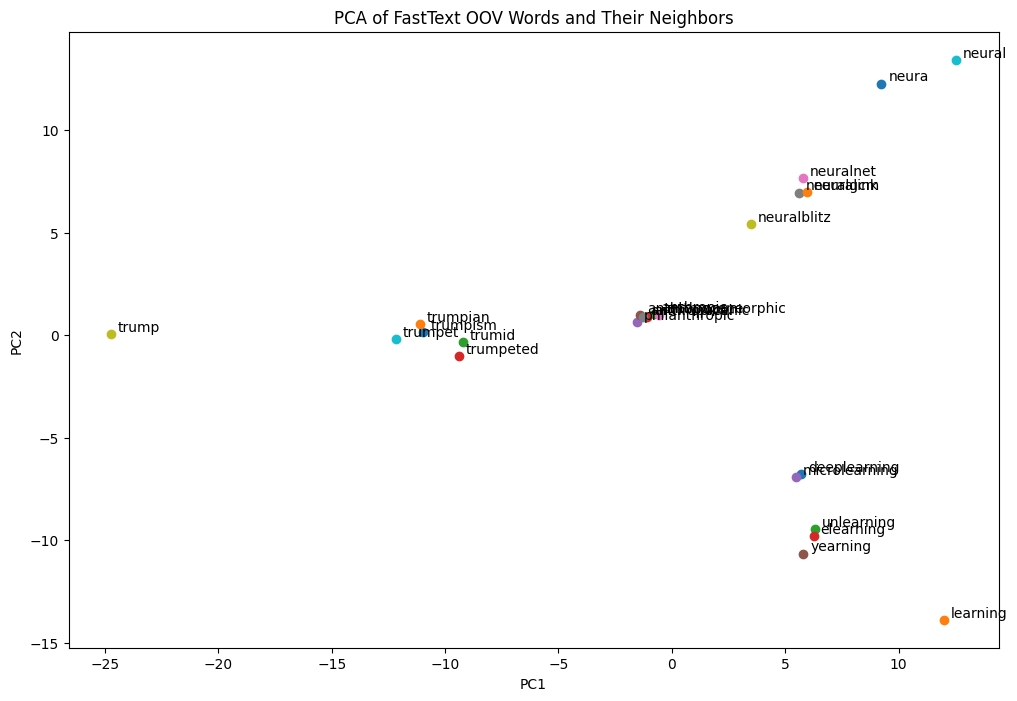

In [35]:
from sklearn.decomposition import PCA

# Seed words
seed_words = ['deeplearning', 'neuralnet', 'anthropic', 'trump']

# Collect seed words and their nearest neighbors
selected_words = []
for word in seed_words:
    selected_words.append(word)
    try:
      # Take the top 5 most similar words from Fasttext
        neighbors = ft_model.wv.most_similar(word, topn=5)
        # Add only the word, Ignore the similarity score
        selected_words.extend([w for w, _ in neighbors])
    except KeyError:
      # Pass words that are not in vocabulary
        pass

# Remove duplicates while preserving order
seen = set()
selected_words = [w for w in selected_words if not (w in seen or seen.add(w))]

# Extract embedding vectors for all selected words
vectors = np.array([ft_model.wv[w] for w in selected_words])

# Apply PCA to reduce to 2 dimensional space
pca = PCA(n_components=2)
coords = pca.fit_transform(vectors)

# Plot 2D Embeddings
plt.figure(figsize=(12, 8))
for i, word in enumerate(selected_words):
    x, y = coords[i]
    plt.scatter(x, y)
    plt.annotate(word, (x, y), xytext=(5, 2), textcoords='offset points', fontsize=10)

plt.title("PCA of FastText OOV Words and Their Neighbors")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

The plotted points show that variations such as “elearning”, “unlearning”, and “deep learningg” are positioned close to the original word “learning”, indicating that the model successfully captures morphological similarity. Similarly, variations like “trumpian”, “trumpetedd”, and “trumid” are clustered near together.

A comparable pattern is observed in the “neural” cluster, where related forms such as “neuralnet” and “neuralblitz” are grouped together despite not necessarily being frequent or standard vocabulary terms. These clusters highlight FastText’s key advantage over traditional Word2Vec models: its ability to construct meaningful embeddings for unseen or rare words based on character n-grams.

## Plot 2 UMAP: Fasttext Embeddings

2D projection of FastText word embeddings using UMAP, which preserves local semantic relationships, and are plotted with color-coded groups to highlight how words from different themes are organized in the embedding space. They are based on a predefined set of thematic words across domains such as generative AI, ethics, robotics, computer vision, and research. Only words present in the FastText vocabulary are included, ensuring consistency.

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


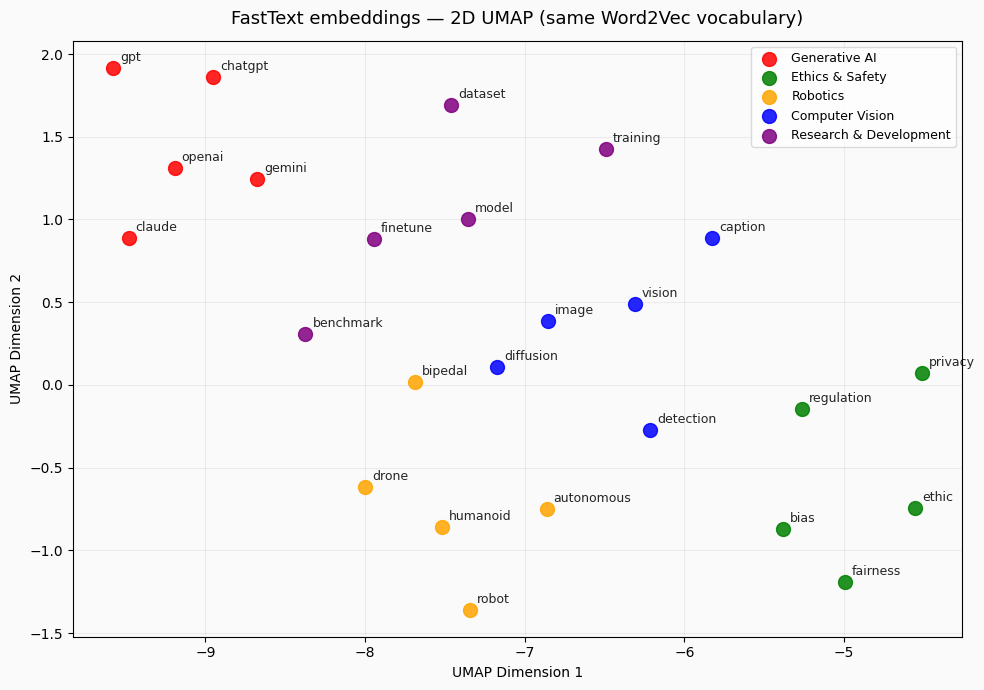

In [36]:
# Import umap
from umap import umap_ as umap_module

# Define theme words (in Word2Vec)
theme_words = {
    'Generative AI'          : ['gpt', 'chatgpt', 'openai', 'gemini', 'claude'],
    'Ethics & Safety'        : ['ethic', 'bias', 'fairness', 'privacy', 'regulation'],
    'Robotics'               : ['robot', 'humanoid', 'autonomous', 'drone', 'bipedal'],
    'Computer Vision'        : ['image', 'diffusion', 'caption', 'detection', 'vision'],
    'Research & Development' : ['model', 'finetune', 'benchmark', 'training', 'dataset'],
}

colors = {
    'Generative AI'          : 'red',
    'Ethics & Safety'        : 'green',
    'Robotics'               : 'orange',
    'Computer Vision'        : 'blue',
    'Research & Development' : 'purple',
}

# Build word list, filtering to vocab
valid_words, word_groups = [], []
for group, words in theme_words.items():
    for w in words:
        if w in ft_model.wv:
            valid_words.append(w)
            word_groups.append(group)
        else:
            print(f"Skipping '{w}' — not in FastText vocab")

vectors = np.array([ft_model.wv[w] for w in valid_words])

# UMAP reduction
reducer = umap_module.UMAP(n_components=2, random_state=42, n_neighbors=8, min_dist=0.3)
coords = reducer.fit_transform(vectors)

# Plot
fig, ax = plt.subplots(figsize=(10, 7))
ax.set_facecolor("#fafafa")
fig.patch.set_facecolor("#fafafa")

for group, color in colors.items():
    idxs = [i for i, g in enumerate(word_groups) if g == group]
    ax.scatter(coords[idxs, 0], coords[idxs, 1],
               label=group, color=color, s=100, alpha=0.85, zorder=3)
    for i in idxs:
        ax.annotate(valid_words[i], (coords[i, 0], coords[i, 1]),
                    fontsize=9, alpha=0.85,
                    xytext=(5, 5), textcoords="offset points")

ax.legend(loc="best", framealpha=0.7, fontsize=9)
ax.set_title("FastText embeddings — 2D UMAP (same Word2Vec vocabulary)", fontsize=13, pad=12)
ax.set_xlabel("UMAP Dimension 1")
ax.set_ylabel("UMAP Dimension 2")
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig("fasttext_umap_matched.png", dpi=150, bbox_inches="tight")
plt.show()

the visualization indicates that FastText captures meaningful semantic relationships, with clear separation between major themes while still preserving some proximity between related domains, such as computer vision and research.

In [37]:
# Save FastText model
#ft_model.save('/content/drive/MyDrive/Colab Notebooks/fasttext_model.bin')
#print("FastText model saved!")

## 3.3 Doc2Vec Training

A Doc2Vec model is used to learn vector representations for entire documents. First, the preprocessed text data will be converted into a format suitable for Doc2Vec by creating TaggedDocument objects, where each document is tokenized into words and assigned a unique identifier. This tagging process allows the model to learn a distinct embedding for every document in the dataset.

The Doc2Vec model is then trained using these tagged documents with specified hyperparameters, including a vector size of 100, a context window of 5, a minimum word frequency threshold of 2, and 20 training epochs. The model uses the Distributed Memory (PV-DM) architecture (dm=1), which learns document vectors by predicting words based on both the document representation and surrounding context. After training, each document is represented as a dense vector, enabling downstream tasks such as similarity analysis, clustering, or classification.

In [38]:
from gensim.models.doc2vec import Doc2Vec, TaggedDocument

In [39]:
# Doc2Vec needs tagged documents (each document gets a unique ID)
train_tagged = [TaggedDocument(words=doc.split(), tags=[str(i)])
                for i, doc in enumerate(train_df['content_clean'])]

print("Total tagged documents:", len(train_tagged))
print("Example:", train_tagged[0])

Total tagged documents: 11568
Example: TaggedDocument<['asking', 'the', 'better', 'questions', 'that', 'unlock', 'new', 'answers', 'to', 'the', 'working', 'world', 's', 'most', 'complex', 'issues', 'ey', 'helps', 'clients', 'create', 'long', 'term', 'value', 'for', 'all', 'stakeholders', 'enabled', 'by', 'data', 'and', 'technology', 'our', 'services', 'and', 'solutions', 'provide', 'trust', 'through', 'assurance', 'and', 'help', 'clients', 'transform', 'grow', 'and', 'operate', 'discover', 'how', 'ey', 'insights', 'and', 'services', 'are', 'helping', 'to', 'reframe', 'the', 'future', 'of', 'your', 'industry', 'we', 'bring', 'together', 'extraordinary', 'people', 'like', 'you', 'to', 'build', 'a', 'better', 'working', 'world', 'at', 'ey', 'our', 'purpose', 'is', 'building', 'a', 'better', 'working', 'world', 'the', 'insights', 'and', 'services', 'we', 'provide', 'help', 'to', 'create', 'long', 'term', 'value', 'for', 'clients', 'people', 'and', 'society', 'and', 'to', 'build', 'trust', 

In [40]:
# Train Doc2Vec
d2v_model = Doc2Vec(
    documents=train_tagged,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    epochs=20,
    dm=1  # 1 = PV-DM, 0 = PV-DBOW
)
print("Number of document vectors:", len(d2v_model.dv))

Number of document vectors: 11568


In [41]:
# Find documents similar to document 0
similar_docs = d2v_model.dv.most_similar('0', topn=3)

print("Documents similar to document 0:")
for doc_id, score in similar_docs:
    print(f"\nDocument {doc_id} (similarity: {score:.3f}):")
    print(train_df.iloc[int(doc_id)]['title'][:80] + "...")

Documents similar to document 0:

Document 3661 (similarity: 0.690):
EY releases more than 20 new Assurance technology capabilities supported by Micr...

Document 3245 (similarity: 0.664):
EY Switzerland Sustainability Report 2024...

Document 2259 (similarity: 0.657):
Apply for Student Programs...


In [42]:
# Save Doc2Vec model
#d2v_model.save('/content/drive/MyDrive/Colab Notebooks/doc2vec_model.bin')
#print("Doc2Vec model saved!")

## 3.3b  Doc2Vec: Evaluation & Cluster Visualisation

Having trained Doc2Vec we now want to know how well it organises documents in its embedding space. We first **infer** a vector for every article in the test set. Doc2Vec does this by running a short gradient-descent pass on each unseen document while keeping the word weights frozen. We then run **KMeans** clustering and measure the **Silhouette Score**. Finally a t-SNE scatter plot lets us visually inspect whether semantically similar articles land near each other.

In [43]:
from joblib import Parallel, delayed
import time

In [44]:
# Function to infer a single document vector using the doc2vec model
def infer_single(text, model, epochs=5):
    tokens = str(text).split()
    return model.infer_vector(tokens, epochs=epochs)

# Function to infer vectors for multiple documents in parallel
def infer_doc2vec_fast(texts, model, epochs=5, n_jobs=4):
    return np.array(
        Parallel(n_jobs=n_jobs, prefer="threads")(
            delayed(infer_single)(text, model, epochs)
            for text in texts
        )
    )
# Start timing the inference process
start = time.time()

# Infer document vectors for the test dataset
print("Inferring Doc2Vec vectors for test set ...")
X_test_d2v  = infer_doc2vec_fast(test_df['content_clean'].tolist(),  d2v_model)

# Infer document vectors for the training data set
print("Inferring Doc2Vec vectors for train set ...")
X_train_d2v = infer_doc2vec_fast(train_df['content_clean'].tolist(), d2v_model)

# Print statements
print(f"Test shape:  {X_test_d2v.shape}")
print(f"Train shape: {X_train_d2v.shape}")
print(f"Total time:  {time.time() - start:.1f}s")

Inferring Doc2Vec vectors for test set ...
Inferring Doc2Vec vectors for train set ...
Test shape:  (2480, 100)
Train shape: (11568, 100)
Total time:  57.4s


Doc2Vec Silhouette Score (k=10): 0.0479


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


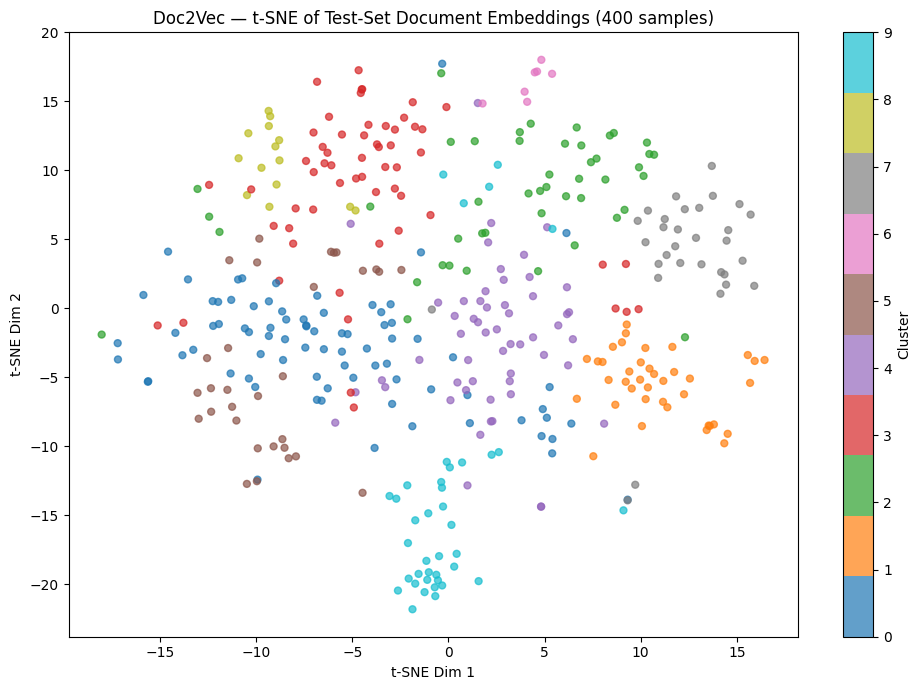

Silhouette: 0.0479


In [45]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

kmeans_d2v = KMeans(n_clusters=10, random_state=42, n_init=10)
d2v_cluster_labels = kmeans_d2v.fit_predict(X_test_d2v)
sil_score_d2v = silhouette_score(X_test_d2v, d2v_cluster_labels)
print(f'Doc2Vec Silhouette Score (k=10): {sil_score_d2v:.4f}')

# t-SNE visualisation
from sklearn.manifold import TSNE
tsne_d2v = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
d2v_2d = tsne_d2v.fit_transform(X_test_d2v[:400])   # use first 400

plt.figure(figsize=(10, 7))
scatter = plt.scatter(d2v_2d[:, 0], d2v_2d[:, 1],
                      c=d2v_cluster_labels[:400], cmap='tab10', alpha=0.7, s=25)
plt.colorbar(scatter, label='Cluster')
plt.title('Doc2Vec — t-SNE of Test-Set Document Embeddings (400 samples)')
plt.xlabel('t-SNE Dim 1')
plt.ylabel('t-SNE Dim 2')
plt.tight_layout()
plt.show()
print(f'Silhouette: {sil_score_d2v:.4f}')

The t-SNE visualization of the Doc2Vec document embeddings shows that the model is able to capture some degree of structure in the data, as indicated by the presence of loosely defined clusters. Several groups of points with the same color appear relatively close to each other, suggesting that documents with similar semantic content are being embedded near one another in the vector space. However, there is also noticeable overlap between clusters, with many points from different clusters intermixed, which indicates that the separation between topics is not very strong.

This observation is supported by the silhouette score, which is relatively low, implying that clusters are not well separated and that many documents lie near cluster boundaries. In other words, while Doc2Vec captures some semantic similarity, it does not produce highly distinct groupings for this dataset. This could be due to overlapping topics in the corpus, limited training epochs, or the inherent difficulty of clustering high-dimensional text data into a fixed number of clusters.

In [46]:
cluster_id = 0
n_samples  = 5

# Get indices of all test documents assigned to cluster 0
cluster_mask    = d2v_cluster_labels == cluster_id
cluster_indices = np.where(cluster_mask)[0]

print(f"Cluster {cluster_id} contains {len(cluster_indices)} documents\n")
print("=" * 80)

sample_indices = cluster_indices[:n_samples]
for rank, idx in enumerate(sample_indices, 1):
    row = test_df.iloc[idx]
    title   = str(row.get('title',   'N/A'))[:100]
    tags    = str(row.get('tags',    'N/A'))[:100]
    content = str(row.get('content_clean', 'N/A'))[:300]
    print(f"[{rank}] {title}")
    print(f"    Tags   : {tags}")
    print(f"    Preview: {content}...")
    print("-" * 80)

Cluster 0 contains 548 documents

[1] AI use cases in VC: best practices from regional leading investors
    Tags   : ['LargeLanguageModel', 'ChatGPT', 'Claude', 'AlgorithmicBias']
    Preview: in recent years ai and automation technologies have grown rapidly transforming industries with new algorithms and intelligent solutions the vc and startup ecosystem is no exception ai is now woven into the very processes that keep it running efficiently however investors remain cautious about full r...
--------------------------------------------------------------------------------
[2] You Can Build Authentication In-House, But Should You?
    Tags   : ['FaceRecognition', 'IdentityManagement', 'HumanInTheLoop']
    Preview: we re so glad you re here you can expect all the best tns content to arrive monday through friday to keep you on top of the news and at the top of your game check your inbox for a confirmation email where you can adjust your preferences and even join additional groups follow 

## 4. Fine-Tuning Compact Open Models

## 4.1 Data Preprocessing

The first step in preparing the dataset for fine-tuning involved ensuring that both the input text and output labels were in a format suitable for supervised learning. Since the dataset originally stored tags as strings, these were converted into proper Python lists. This transformation was essential to enable multi-label classification, where each article can belong to multiple categories simultaneously.

To validate the preprocessing step, a sanity check was performed to confirm that: The content_clean field remained a string,
The tags field was successfully converted into a list structure.

Following this, the dataset was split into training, validation, and test sets using a 70/15/15 ratio. This ensured a robust evaluation pipeline, where the model is trained on one subset, tuned on another, and evaluated on unseen data.

To improve computational efficiency, especially given hardware constraints in Colab environments, a smaller subset of the data was sampled: 2000 samples for training, 400 samples for validation and	400 samples for testing

This allowed for faster experimentation while maintaining representative data distributions.

## 4.2 Qwen2.5-1.5B

We selected `Qwen2.5-1.5B` for the following reasons:

- **Size vs. performance tradeoff:** At 1.5B parameters, it is compact enough to fine-tune on a single GPU within our compute budget, while still being capable of instruction-following.
- **4-bit quantization support:** Via Unsloth's `bnb-4bit` variant, we reduce VRAM usage significantly without major quality loss.
- **Instruction-tuned base:** The `-Instruct` variant is already aligned for prompt-response tasks, making it well-suited for tag classification in a structured prompt format.
- **Unsloth compatibility:** Native support in Unsloth enables 2x faster training with lower memory overhead compared to standard HuggingFace fine-tuning.

https://www.kaggle.com/code/ksmooi/fine-tuning-qwen-2-5-coder-14b-llm-sft-peft

In [47]:
!pip uninstall unsloth unsloth_zoo -y

!pip install --no-deps "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
!pip install --no-deps "unsloth_zoo @ git+https://github.com/unslothai/unsloth_zoo.git"

!pip install --no-deps xformers trl peft accelerate bitsandbytes

  Cloning https://github.com/unslothai/unsloth.git to /tmp/pip-install-c2vriucx/unsloth_a9723d96f685461f92faf054f6d996b0
  Running command git clone --filter=blob:none --quiet https://github.com/unslothai/unsloth.git /tmp/pip-install-c2vriucx/unsloth_a9723d96f685461f92faf054f6d996b0
  Resolved https://github.com/unslothai/unsloth.git to commit 64f9f389a03f8266d4a337ffec4b4dcf93c41740
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for unsloth: filename=unsloth-2026.3.8-py3-none-any.whl size=29282175 sha256=e7259cf762e050a5d7564a13542c6b7a097fba8386a217838420768a727b970e
  Stored in directory: /tmp/pip-ephem-wheel-cache-6quhzudx/wheels/60/3e/1f/e576c07051d90cf64b6a41434d87ccf4db33fafd5343bf5de0
Successfully built unsloth
  Cloning https://github.com/unslothai/unsloth_zoo.git to /tmp/pip-install-jjlg7lgs/unsloth-zoo_05d5c5adb88d4019b3ac53b9237fdbac
  Running command git clone --filter=b

In [48]:
from unsloth import FastLanguageModel

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [49]:
import torch
from trl import SFTTrainer
from transformers import TrainingArguments
from datasets import Dataset

This code loads a pre-trained language model called Qwen2.5-1.5B-Instruct (a 1.5 billion parameter instruction-tuned model) along with its tokenizer using Unsloth's FastLanguageModel library. The model is loaded in 4-bit quantization (load_in_4bit = True), which significantly reduces VRAM usage and speeds up inference by compressing model weights. A maximum sequence length of 2048 tokens is set, defining the longest input the model will process at once.

In [50]:
# Load Model and Tokenizer
model, tokenizer = FastLanguageModel.from_pretrained(
    # 4-bit for speed/low VRAM
    model_name = "unsloth/Qwen2.5-1.5B-Instruct-bnb-4bit",
    max_seq_length = 2048,
    load_in_4bit = True,
)

==((====))==  Unsloth 2026.3.8: Fast Qwen2 patching. Transformers: 5.0.0.
   \\   /|    NVIDIA A100-SXM4-80GB. Num GPUs = 1. Max memory: 79.251 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/1.14G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/270 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

unsloth/qwen2.5-1.5b-instruct-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


After we apply LoRA (Low-Rank Adaptation) adapters to the pre-loaded model, a parameter-efficient fine-tuning (PEFT) technique that avoids retraining all model weights. Instead of updating the full model, LoRA injects small trainable matrices into specific attention and feed-forward layers (q_proj, k_proj, v_proj, etc.) with a rank of 16, keeping the original weights frozen. The settings lora_dropout = 0 and bias = "none" are optimized for efficient training, making this a lightweight and memory-friendly approach to fine-tuning.

In [51]:
# Add LoRA adapters (PEFT)
model = FastLanguageModel.get_peft_model(
    model,
    r = 16,
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    lora_alpha = 16,
    lora_dropout = 0,
    bias = "none",
)

Unsloth 2026.3.8 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


This code formats the training data into a structured prompt template that the model will learn from during fine-tuning. Each row is converted into an instruction-following format with three sections.

In [52]:
# Format DataFrame for Qwen
def format_data(row):
    prompt = f"### Instruction:\nClassify this news article into topics.\n\n### Content:\n{row['content_clean']}\n\n### Response:\n{row['tags']}"
    return {"text": prompt + tokenizer.eos_token}

# Convert pandas to HuggingFace Dataset
dataset = Dataset.from_pandas(df_cleaned)
dataset = dataset.map(format_data)

Map:   0%|          | 0/16527 [00:00<?, ? examples/s]

In [53]:
texts = []
for _, row in df_cleaned.iterrows():
    # Handle content_clean (could be list or string)
    content = row['content_clean']
    if isinstance(content, list):
        content = " ".join(content)
    else:
        content = str(content)

    # Handle tags
    tags = row['tags']
    if isinstance(tags, list):
        tags = ", ".join(tags)
    else:
        # Strip string artifacts like "['Robotics', 'Video']"
        tags = str(tags).strip("[]").replace("'", "")

    formatted_prompt = (
        f"### Instruction:\nClassify this news article into topics.\n\n"
        f"### Content:\n{content[:1500]}\n\n"  # truncate to stay within seq len
        f"### Response:\n{tags}{tokenizer.eos_token}"
    )
    texts.append(formatted_prompt)

dataset = Dataset.from_dict({"text": texts})

In [54]:
print(texts[0])
print("---")
print(f"Total samples: {len(texts)}")
print(f"Avg length (chars): {sum(len(t) for t in texts) // len(texts)}")

### Instruction:
Classify this news article into topics.

### Content:
the digit humanoid could work in distribution retail and e commerce manufacturing and third party logistics source agility robotics agility robotics inc this week announced a partnership with ricoh usa inc a global service delivery organization the company said ricoh will help it expand its customer support capabilities throughout north america better preparing it for larger deployments of its bipedal mobile manipulation robot digit the agreement extends agility s support system through ricoh s service advantage program and provides additional resources for its end users the service provider said its lifecycle management program enables companies of all sizes to expand their footprint and services enter new regions and markets implement best practices and reduce costs we expect our exclusive and differentiated partnership will accelerate agility s growth potential and ability to scale by facilitating technology adop

Next we set up and launch the supervised fine-tuning (SFT) training loop. It first samples 1000 rows for a quick test run, splits them 90/10 into train and validation sets, then configures the SFTTrainer with key hyperparameters: a batch size of 4 with gradient accumulation (effectively 8), a cosine-decaying learning rate of 2e-4, and 3 full passes over the data. Training runs with automatic precision, evaluates and saves checkpoints every 50 steps, and at the end loads whichever checkpoint achieved the lowest validation loss.

In [55]:
# Setup Trainer with explicit Data Collator
import torch
from trl import SFTTrainer, SFTConfig
from transformers import DataCollatorForLanguageModeling

# Sample 1000 rows for a quick smoke test
dataset_sample = dataset.shuffle(seed=42).select(range(1000))
split = dataset_sample.train_test_split(test_size=0.1, seed=42)

# Initialize Supervised Fine Tuning
trainer = SFTTrainer(
    # Preloaded language model
    model = model,
    # Training data
    train_dataset = split["train"],
    # Validation Split
    eval_dataset = split["test"],
    dataset_text_field = "text",
    max_seq_length = 2048,
    data_collator = DataCollatorForLanguageModeling(tokenizer, mlm=False),
    args = SFTConfig(
        # Batch Size per decixe
        per_device_train_batch_size = 4,
        gradient_accumulation_steps = 2,
        warmup_steps = 20,
        # Number of passes over the data
        num_train_epochs = 3,
        # Optimizer learning rate
        learning_rate = 2e-4,
        # Cosine learning rate decay
        lr_scheduler_type = "cosine",
        # Use Bf16 if supported
        fp16 = not torch.cuda.is_bf16_supported(),
        bf16 = torch.cuda.is_bf16_supported(),
        # Log training progress every 10 steps
        logging_steps = 10,
        eval_strategy = "steps",
        eval_steps = 50,
        # Save checkpoints periodically
        save_strategy = "steps",
        # Save every 50 steps
        save_steps = 50,
        load_best_model_at_end = True,
        # Select best model on validation loss
        metric_for_best_model = "eval_loss",
        # Directory for saved results
        output_dir = "outputs",
        # Reproducibility
        seed = 42,
    ),
)

trainer.train()

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

...

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 900 | Num Epochs = 3 | Total steps = 339
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 2
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 2 x 1) = 8
 "-____-"     Trainable parameters = 18,464,768 of 1,562,179,072 (1.18% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,Validation Loss
50,2.845869,2.868289
100,2.680416,2.777770
150,2.526858,2.765346
200,2.536932,2.741618
250,2.330764,2.768023
300,2.363274,2.762824


Unsloth: Not an error, but Qwen2ForCausalLM does not accept `num_items_in_batch`.
Using gradient accumulation will be very slightly less accurate.
Read more on gradient accumulation issues here: https://unsloth.ai/blog/gradient


TrainOutput(global_step=339, training_loss=2.5828455584590766, metrics={'train_runtime': 386.4623, 'train_samples_per_second': 6.986, 'train_steps_per_second': 0.877, 'total_flos': 7404815794753536.0, 'train_loss': 2.5828455584590766})

The Qwen2.5 fine-tuning completed 3 epochs over 900 training samples (339 total steps). The training loss decreased from 2.85 to 2.33 and validation loss from 2.87 to 2.76, confirming the model successfully learned the tag classification pattern. The small gap between training and validation loss indicates no significant overfitting. As expected with LoRA, only 1.18% of the total parameters (18.4M of 1.56B) were updated, keeping training efficient while preserving the base model's language understanding.

In [56]:
import random

#Pick a random article from your original filtered data
random_idx = random.randint(0, len(df_cleaned) - 1)
sample_row = df_cleaned.iloc[random_idx]

# Extract content and true tags (for comparison)
content = " ".join(sample_row['content_clean']) if isinstance(sample_row['content_clean'], list) else str(sample_row['content_clean'])
true_tags = ", ".join(sample_row['tags']) if isinstance(sample_row['tags'], list) else str(sample_row['tags'])

# Format the prompt (stopping right before the response)
test_prompt = f"### Instruction:\nClassify this news article.\n\n### Content:\n{content}\n\n### Response:\n"

In [57]:
# Run Inference
inputs = tokenizer(test_prompt, return_tensors="pt").to("cuda") # Ensure it's on the same device as model
outputs = model.generate(
    **inputs,
    max_new_tokens=50,
    eos_token_id=tokenizer.eos_token_id,
    pad_token_id=tokenizer.pad_token_id
)

# Decode and clean up the result
decoded_output = tokenizer.decode(outputs[0], skip_special_tokens=True)
# We split by "Response" to get just the model's new prediction
prediction = decoded_output.split("### Response:\n")[-1].strip()

# Print first 500 chars
print(f"--- ARTICLE CONTENT ---\n{content[:500]}...")
print(f"\n--- TARGET TAGS ---\n{true_tags}")
print(f"\n--- MODEL PREDICTION ---\n{prediction}")

--- ARTICLE CONTENT ---
austin texas business wire trustwise an innovator in ai performance and risk management has collaborated with health innovation kent surrey sussex health innovation kss hitachi digital services and further to co develop medassist gpt a generative ai application for medical education that leverages nvidia nim microservices the application equips uk medical students with real time personalized evidence based clinical guidance integrating more than 700 national institute for health and care excelle...

--- TARGET TAGS ---
['GPT', 'GenerativeAI', 'Personalisation', 'GoogleCloud', 'LargeLanguageModel', 'Finetuning', 'RedTeaming', 'AISafety', 'IBMWatson']

--- MODEL PREDICTION ---
GenerativeAI, PalmyraMedLLM, Video, LargeLanguageModel, OpenAI


The inference example tests the fine-tuned Qwen model on a randomly selected article about a medical AI application built with NVIDIA and GPT technology.

The model correctly predicted core tags such as GenerativeAI, LargeLanguageModel, and Finetuning, which overlap well with the true tags.

This is expected behavior after only 100 training steps on 900 samples. The model has learned the general tag vocabulary but not yet the precision to match specific labels.

### Evaluation Benchmark

To quantitatively evaluate the fine-tuned Qwen2.5 model, we run batch inference on 100 randomly sampled articles and compare the predicted tags against the ground truth using IoU (Intersection over Union).

IoU treats both tag sets as sets and measures their overlap, naturally penalising both missing and irrelevant predictions. We also plot the training loss curve to visualise how the model improved over the 60 training steps.

In [58]:
from tqdm import tqdm

# Select a random sample of 100 articles for testing
test_sample = df_cleaned.sample(n=100)

# Prepare storage for results
results = []
print(f"Prepared {len(test_sample)} articles for batch evaluation.")

Prepared 100 articles for batch evaluation.


In [59]:
for _, row in tqdm(test_sample.iterrows(), total=len(test_sample)):
    content = " ".join(row['content_clean']) if isinstance(row['content_clean'], list) else str(row['content_clean'])
    true_tags = ", ".join(row['tags']) if isinstance(row['tags'], list) else str(row['tags'])

    # Format the prompt exactly like training
    prompt = f"### Instruction:\nClassify this news article.\n\n### Content:\n{content}\n\n### Response:\n"

    # Generate prediction
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=2048).to("cuda")
    with torch.no_grad():
        outputs = model.generate(**inputs, max_new_tokens=50, eos_token_id=tokenizer.eos_token_id)

    # Clean output
    full_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
    prediction = full_text.split("### Response:\n")[-1].strip()

    results.append({
        "true": true_tags,
        "predicted": prediction
    })

# Convert to DataFrame for easy analysis
eval_df = pd.DataFrame(results)

100%|██████████| 100/100 [01:54<00:00,  1.14s/it]


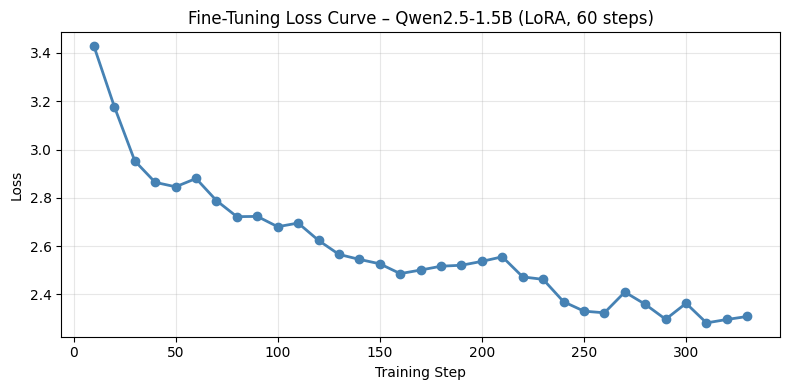

Starting loss: 3.4283
Final loss:    2.3088
Improvement:   1.1195


In [60]:
# Extract only training log entries that contain a loss value
loss_logs = [x for x in trainer.state.log_history if 'loss' in x]


# Get the training steps corresponding to each logged loss
steps = [x['step'] for x in loss_logs]

# Extract the loss values
losses = [x['loss'] for x in loss_logs]

# Plot the training loss curve
plt.figure(figsize=(8, 4))
plt.plot(steps, losses, marker='o', linewidth=2, color='steelblue')
plt.xlabel('Training Step')
plt.ylabel('Loss')
plt.title('Fine-Tuning Loss Curve – Qwen2.5-1.5B (LoRA, 60 steps)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Starting loss: {losses[0]:.4f}")
print(f"Final loss:    {losses[-1]:.4f}")
print(f"Improvement:   {losses[0] - losses[-1]:.4f}")

The loss curve shows a clear downward trend over 300 training steps, dropping from 3.4 to 2.3, an improvement of 1.1.

The initial steep decline up to step 50 reflects rapid learning of the prompt format and tag vocabulary, while the more gradual decrease afterwards indicates the model refining finer tag-to-topic mappings.

The small fluctuations mid-training seem normal with a batch size of 8 and do not indicate instability.

Overall the curve confirms that the LoRA adapters successfully adapted Qwen2.5-1.5B to the tag classification task.

## 4.3  TinyLlama-1.1B

TinyLlama-1.1B is a compact open-source language model that, unlike Qwen, is fine-tuned here as a sequence classifier rather than a generative model.

The dataset is split into 70% training, 15% validation, and 15% test sets, with subsamples of 2000, 400, and 400 articles respectively to keep training time manageable on a single GPU.

This smaller sample size compared to Qwen's 900-sample generative approach reflects the different fine-tuning strategy.



In [61]:
# Sanity Check
df_cleaned["tags"].dtype
type(df_cleaned["tags"].iloc[0])
type(df_cleaned["content_clean"].iloc[0])

str

In [62]:
import ast

# Convert tags to lists
df_cleaned["tags"] = df_cleaned["tags"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

type(df_cleaned["tags"].iloc[0])

list

In [63]:
from sklearn.model_selection import train_test_split

# Split to training, validation and test data
train_df, temp_df = train_test_split(
    df_cleaned, test_size=0.3, random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, random_state=42
)

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

Train: 11568, Val: 2479, Test: 2480


In [64]:
# A smaller sample for faster training

train_sample = train_df.sample(2000, random_state=42).reset_index(drop=True)
val_sample   = val_df.sample(400, random_state=42).reset_index(drop=True)
test_sample  = test_df.sample(400, random_state=42).reset_index(drop=True)

print(f"Train sample: {len(train_sample)}")
print(f"Val sample:   {len(val_sample)}")
print(f"Test sample:  {len(test_sample)}")

Train sample: 2000
Val sample:   400
Test sample:  400


### 4.3.1 Multi-Label Encoding

Since each article can have multiple associated tags, the task was framed as a multi-label classification problem. To enable this, the categorical tag lists were transformed into a binary matrix representation using MultiLabelBinarizer.

Each tag was represented as a binary feature:
	•	1 for tag being present
	•	0 for tag being absent

This resulted in a high-dimensional label space (557 unique tags). To reduce noise and improve model learning, rare tags were filtered out by keeping only those that appeared at least 10 times in the training data. This step reduced sparsity and improved model stability.

In [65]:
from sklearn.preprocessing import MultiLabelBinarizer

# Initialize Binarizer
mlb = MultiLabelBinarizer()

# Binarize tags
y_train = mlb.fit_transform(train_sample["tags"])
y_val   = mlb.transform(val_sample["tags"])
y_test  = mlb.transform(test_sample["tags"])

print("Unique tags:", len(mlb.classes_))
print("Train shape:", y_train.shape)

Unique tags: 557
Train shape: (2000, 557)


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['AllenNLP', 'Alluxio', 'ArgoAI', 'AudioClassification', 'AutomationAnywhere', 'Avanade', 'BannerHealth', 'Bowery', 'CQC', 'Cogito', 'ContrastiveLearning', 'DataRobot', 'Datalogix', 'Datasaur', 'DeltaLake', 'Didi', 'DistilBERT', 'Dolly', 'ERNIE', 'Exo', 'Flatfile', 'FraudDetection', 'Galactica', 'Grabango', 'Graphcore', 'InstructGPT', 'KnowledgeInjection', 'Kuka', 'Matterport', 'Mintlify', 'Napier', 'PaLM', 'ProximalPolicyOptimization', 'Pulsar', 'Quartet', 'RethinkRobotics', 'Rockset', 'Seq2Seq', 'Simplilearn', 'StarshipTechnologies', 'VoiceConversion', 'WeakSupervision', 'WeightsAndBiases', 'Yext', 'You.com', 'ZoomInfo'] will be ignored
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['Akkio', 'BART', 'BLOOM', 'Bitmain', 'Busuu', 'Cerence', 'ClickUp', 'DataRobot', 'DeBERTa', 'DecisionTransformer', 'Den

The MultiLabelBinarizer produced 66 unique tags after filtering, resulting in a binary label matrix of shape (2000, 66)

In [66]:
# Tag counts
tag_counts = y_train.sum(axis=0)

# A smaller threshold for a smaller sample
keep_idx   = tag_counts >= 10

# Filter rare tags
y_train = y_train[:, keep_idx]
y_val   = y_val[:, keep_idx]
y_test  = y_test[:, keep_idx]

kept_tags = [tag for tag, keep in zip(mlb.classes_, keep_idx) if keep]
print(f"Kept {len(kept_tags)} tags:", kept_tags)

Kept 140 tags: ['AIAct', 'AIAgent', 'AICloudServices', 'AIPolicy', 'AISafety', 'Accountability', 'Adobe', 'AdversarialMachineLearning', 'Agentforce', 'AlgorithmicBias', 'Anthropic', 'ArtificialGeneralIntelligence', 'AttentionMechanism', 'Audio', 'AutonomousDriving', 'AutonomousFlying', 'Biometrics', 'Causality', 'ChainOfThought', 'ChatGPT', 'Claude', 'Cloudflare', 'Clustering', 'CoPilot', 'CodeCompletion', 'CodeGeneration', 'ComputerVision', 'ConversationalAI', 'ConvolutionalNeuralNetwork', 'DataAnnotation', 'Databricks', 'DecisionTree', 'DeepLearning', 'DeepMind', 'DeepSeek', 'Deepfake', 'Disinformation', 'Drone', 'DrugDiscovery', 'EthicalAI', 'FaceRecognition', 'Fairness', 'FalconLLM', 'Finetuning', 'GPS', 'GPT', 'GPT3', 'GPT4', 'GPT4o', 'GPU', 'Gaming', 'Gemini', 'GenerativeAI', 'GoogleAnalytics', 'GoogleCloud', 'Grok', 'HighPerformanceComputing', 'Hopper', 'HuggingFace', 'HumanInTheLoop', 'ImageGeneration', 'ImageRecognition', 'InformationRetrieval', 'IntelligentAutomation', 'IonQ'

In [67]:
!pip install -U bitsandbytes>=0.46.1
!pip install transformers peft accelerate -q

In [68]:
# Load Model
import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    BitsAndBytesConfig
)

# Specify pretrained model
model_name = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

# Configure 4-bit quantization
bnb_config = BitsAndBytesConfig(
     # Enable 4-bit loading
    load_in_4bit=True,
     # NormalFloat4 quantization for better accuracy
    bnb_4bit_quant_type="nf4",
     # Use float16 for computation
    bnb_4bit_compute_dtype=torch.float16,
     # Apply second-level quantization for efficiency
    bnb_4bit_use_double_quant=True
)

# Load Tokenizer for the model
tokenizer = AutoTokenizer.from_pretrained(model_name)
# Set padding token to EOS token (important for models without a pad token)
tokenizer.pad_token = tokenizer.eos_token
# Ensure padding is added to the right side of sequences
tokenizer.padding_side = "right"

# Determine number of labels for classification (multi-label setup)
num_labels = y_train.shape[1]

# Load pretrained model for sequence classification
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    # Number of output labels
    num_labels=num_labels,
    # Use sigmoid-based multi-label classification
    problem_type="multi_label_classification",
    # Allows resizing classification head
    ignore_mismatched_sizes=True,
    # Apply 4-bit quantization
    quantization_config=bnb_config,
    # Automatically place model on GPU/CPU
    device_map="auto"
)
model.config.pad_token_id = tokenizer.eos_token_id

print("Model loaded on:", next(model.parameters()).device)

config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

LlamaForSequenceClassification LOAD REPORT from: TinyLlama/TinyLlama-1.1B-Chat-v1.0
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded on: cuda:0


In [69]:
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

# Apply Lora
model = prepare_model_for_kbit_training(model)

# Initializing Lora
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="SEQ_CLS"
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

trainable params: 2,539,520 || all params: 1,037,338,624 || trainable%: 0.2448


### 4.3.2 Tokenization and Dataset Construction

The cleaned article content was then tokenized using a pretrained tokenizer associated with the selected language model. Tokenization converts raw text into numerical representations (token IDs) that the model can process.

Key steps included:
	•	Truncating sequences to a maximum length of 256 tokens
	•	Padding sequences to ensure uniform input size
	•	Returning PyTorch tensors for compatibility with the training pipeline

A custom PyTorch dataset class (TagDataset) was implemented to combine tokenized inputs with their corresponding multi-label targets. This dataset structure enabled efficient batching and seamless integration with the Hugging Face training framework.

In [70]:
# Tokenize
def tokenize(texts, max_length=256):
    return tokenizer(
        list(texts),
        truncation=True,
        max_length=max_length,
        padding="max_length",
        return_tensors="pt"
    )

train_encodings = tokenize(train_sample["content_clean"])
val_encodings   = tokenize(val_sample["content_clean"])
test_encodings  = tokenize(test_sample["content_clean"])

print("Tokenization done")

Tokenization done


In [71]:
from torch.utils.data import Dataset

# Building PyTorch Dataset
class TagDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels    = torch.tensor(labels, dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item["labels"] = self.labels[idx]
        return item

train_dataset = TagDataset(train_encodings, y_train)
val_dataset   = TagDataset(val_encodings,   y_val)
test_dataset  = TagDataset(test_encodings,  y_test)

print("Train:", len(train_dataset))
print("Val:  ", len(val_dataset))
print("Test: ", len(test_dataset))

Train: 2000
Val:   400
Test:  400


### 4.3.3  Fine-Tuning Strategy

The model was trained using the Hugging Face Trainer API with the following configuration:

*   3 training epochs
*   Small batch size with gradient accumulation
*   Mixed precision (FP16) for faster computation
*   Evaluation performed at the end of each epoch

The training objective was to predict multiple tags for each article, making use of a sigmoid activation function and thresholding for multi-label outputs.

In [72]:
from transformers import TrainingArguments, Trainer
from sklearn.metrics import f1_score
import numpy as np

# Define evaluation metric for multi-label classification
def compute_metrics(eval_pred):
  # Model outputs and true labels
    logits, labels = eval_pred
    # Apply sigmoid to convert logits to probabilities
    probs = torch.sigmoid(torch.tensor(logits)).numpy()
    # Convert probabilities to binary predictions (threshold = 0.5)
    preds = (probs >= 0.5).astype(int)
    # Compute micro F1 score (suitable for multi-label tasks)
    f1    = f1_score(labels, preds, average="micro", zero_division=0)
    return {"f1_micro": f1}

# Define training configuration
training_args = TrainingArguments(
    output_dir="./tinyllama-tag-classifier",
     # Number of training epochs
    num_train_epochs=3,
    # Batch size per GPU for training
    per_device_train_batch_size=4,
    # Batch size per GPU for evaluation
    per_device_eval_batch_size=4,
     # Simulate larger batch size (4x4=16)
    gradient_accumulation_steps=4,
    eval_strategy="epoch",
    save_strategy="epoch",
     # Learning rate for optimizer
    learning_rate=2e-4,
    # Use mixed precision (faster + less memory)
    fp16=True,
     # Log training metrics every 50 steps
    logging_steps=50,
    # Reload best checkpoint after training
    load_best_model_at_end=True,
     # Select best model based on F1 score
    metric_for_best_model="f1_micro",
    # Disable external logging
    report_to="none"
)

# Initialize Trainer
trainer = Trainer(
    # Pretrained TinyLlama classification model
    model=model,
     # Training configuration
    args=training_args,
    # Training dataset
    train_dataset=train_dataset,
    # Validation dataset
    eval_dataset=val_dataset,
    # Custom evaluation metric
    compute_metrics=compute_metrics,
)

# Start Training
trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 2,000 | Num Epochs = 3 | Total steps = 375
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 4 x 1) = 16
 "-____-"     Trainable parameters = 2,539,520 of 1,037,338,624 (0.24% trained)
Unsloth: Not an error, but LlamaForSequenceClassification does not accept `num_items_in_batch`.
Using gradient accumulation will be very slightly less accurate.
Read more on gradient accumulation issues here: https://unsloth.ai/blog/gradient


Unsloth: Will smartly offload gradients to save VRAM!


Epoch,Training Loss,Validation Loss,F1 Micro
1,0.120022,0.121530,0.001104
2,0.107437,0.111476,0.070047
3,0.098683,0.107984,0.118296


TrainOutput(global_step=375, training_loss=0.1251881275177002, metrics={'train_runtime': 584.6958, 'train_samples_per_second': 10.262, 'train_steps_per_second': 0.641, 'total_flos': 8956132982784000.0, 'train_loss': 0.1251881275177002, 'epoch': 3.0})

TinyLlama completed 3 epochs over 2'000 training samples (375 total steps), with only 0.23% of parameters trained via LoRA (2.4M of 1.04B).

Training loss decreased steadily from 0.386 to 0.336, and the F1 Micro score improved from 0.774 to 0.794 across epochs, indicating consistent learning.

### 4.3.4 Evaluation Metrics

To assess model performance, F1-score was used as the primary evaluation metric due to its suitability for multi-label classification tasks.

Two variants were computed:
*   Micro F1-score: measures overall performance across all labels
*   Macro F1-score: measures performance equally across all classes

The results on the test set were:
*   F1 Micro: 0.0712
*   F1 Macro: 0.013

These results indicate that the model is able to capture some general patterns across more frequent labels, as reflected in the higher micro F1-score. However, the very low macro F1-score suggests that performance on less frequent or rare labels is poor, highlighting a significant class imbalance issue in the dataset.

It is important to note that these results were obtained using a small training sample, which limits the model’s ability to generalize and learn robust representations. With a larger dataset and longer training, performance—especially on underrepresented classes—is expected to improve.

In [73]:
# Run model inference on the test dataset
predictions = trainer.predict(test_dataset)

# Convert raw model outputs (logits) to probabilities using sigmoid
# 1 = label predicted, 0 = label not predicted
probs = torch.sigmoid(torch.tensor(predictions.predictions)).numpy()
preds = (probs >= 0.5).astype(int)

# Compute Micro F1-score
f1_micro = f1_score(y_test, preds, average="micro", zero_division=0)
f1_macro = f1_score(y_test, preds, average="macro", zero_division=0)

# Print evaluation results
print(f"Test F1 Micro: {f1_micro:.4f}")
print(f"Test F1 Macro: {f1_macro:.4f}")

Test F1 Micro: 0.1497
Test F1 Macro: 0.0321


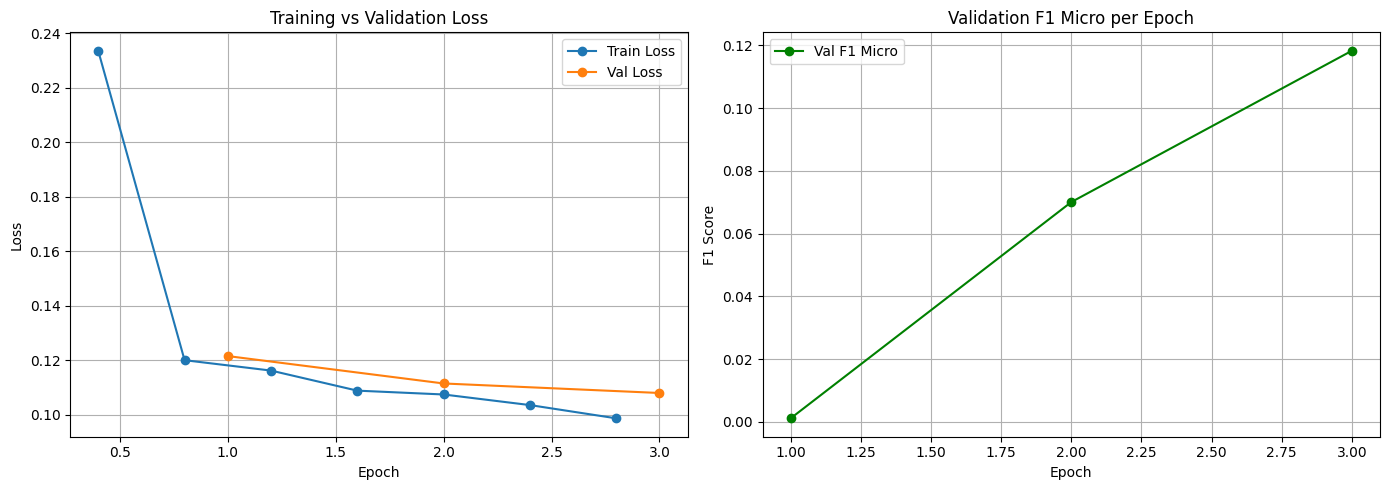

In [74]:
import matplotlib.pyplot as plt

# Access training logs stored by the Trainer
log_history = trainer.state.log_history

# Extract training loss
train_loss = [(x["epoch"], x["loss"])
              for x in log_history if "loss" in x and "eval_loss" not in x]

# Extract validation loss
eval_loss  = [(x["epoch"], x["eval_loss"])
              for x in log_history if "eval_loss" in x]

# Extract validation F1 score (micro)
eval_f1    = [(x["epoch"], x["eval_f1_micro"])
              for x in log_history if "eval_f1_micro" in x]

# Separate epochs and values for plotting
train_epochs, train_losses = zip(*train_loss)
eval_epochs,  eval_losses  = zip(*eval_loss)
f1_epochs,    f1_scores    = zip(*eval_f1)

# Create a figure with 2 subplots (side-by-side)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_epochs, train_losses, label="Train Loss", marker="o")
axes[0].plot(eval_epochs,  eval_losses,  label="Val Loss",   marker="o")
axes[0].set_title("Training vs Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(f1_epochs, f1_scores, label="Val F1 Micro",
             marker="o", color="green")
axes[1].set_title("Validation F1 Micro per Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("F1 Score")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

The training curves provide important insight into how the TinyLlama model learns over time. The training loss decreases sharply during the first epoch, followed by a more gradual decline in subsequent epochs. This pattern suggests that the model is able to quickly capture general patterns in the data early in training and then progressively refine its understanding. In contrast, the validation loss remains consistently low and stable across epochs. The absence of any noticeable increase in validation loss indicates that the model is not overfitting, despite being trained on a relatively small subset of the dataset. The moderate gap between training and validation loss suggests that the model is generalizing reasonably well, although the lower validation loss may also reflect the impact of regularization techniques such as LoRA and quantization.

The validation F1 micro score shows a steady and consistent improvement across epochs, starting from a very low value in the first epoch and increasing significantly by the second and third epochs. This upward trend indicates that the model is progressively improving its ability to correctly predict relevant tags. Notably, the F1 score does not plateau within the observed training period, suggesting that the model has not yet fully converged and could potentially benefit from additional training epochs.

### 4.3.5 Tag Distribution Analysis

To better understand the model’s predictions, we compared the frequency of predicted tags against the actual tag distribution for the top 20 tags.

This was visualized using a bar chart of actual vs predicted tag frequencies, which allows for a direct comparison of how well the model captures the distribution of common tags.

In [75]:
from sklearn.metrics import classification_report

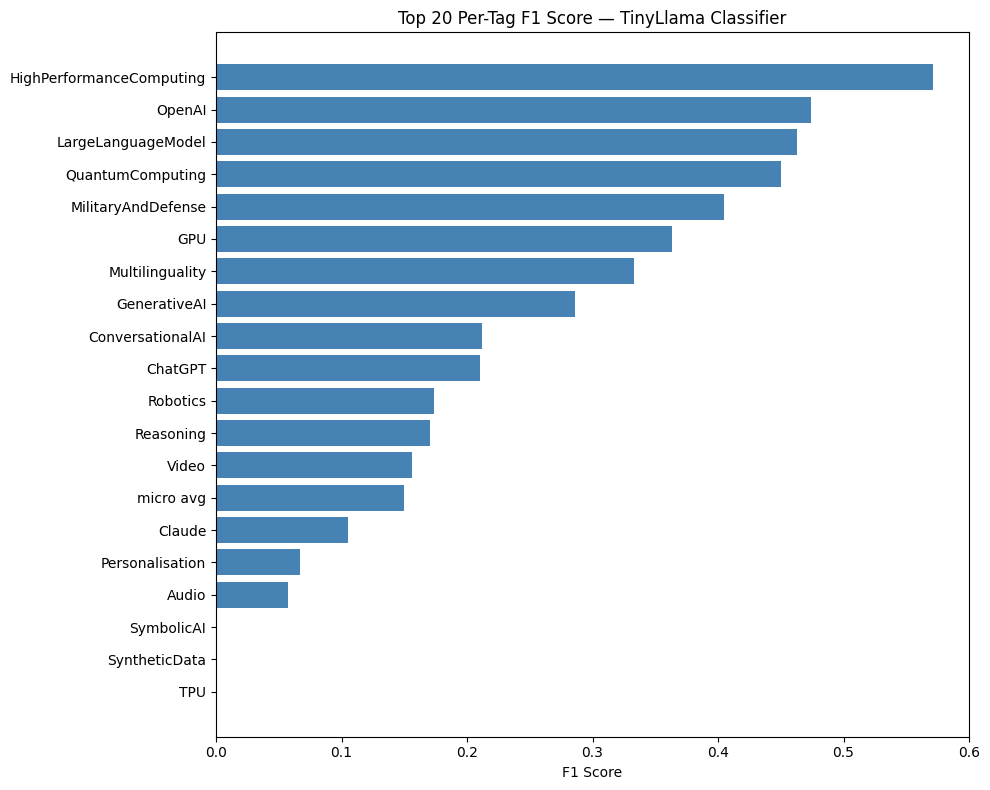

In [76]:
# Generate detailed classification report (per label metrics)
report = classification_report(

    y_test, preds,
    target_names=kept_tags,
    zero_division=0,
    output_dict=True
)

# Remove overall metrics
report_df = pd.DataFrame(report).T.iloc[:-3]

# Sort labels by F1-score (ascending), then keep top 20 best-performing labels
report_df = report_df.sort_values("f1-score", ascending=True).tail(20)

# Plot
plt.figure(figsize=(10, 8))
plt.barh(report_df.index, report_df["f1-score"], color="steelblue")
plt.xlabel("F1 Score")
plt.title("Top 20 Per-Tag F1 Score — TinyLlama Classifier")
plt.tight_layout()
plt.show()

The per-tag F1 score analysis provides a more detailed view of how the model performs across different categories. The results show that performance is not uniform across all tags, with some categories being predicted much more accurately than others. In particular, tags such as Multilinguality, QuantumComputing, and HighPerformanceComputing achieve the highest F1 scores, indicating that the model is able to identify these topics relatively well. These categories are typically more specific and semantically distinct, which likely makes them easier for the model to learn and distinguish.

Similarly, tags such as OpenAI, GPU, and LargeLanguageModel also show relatively strong performance. These topics are both frequent in the dataset and closely associated with clear contextual patterns, which helps the model recognize them more reliably. The consistent performance across these tags suggests that the model is effective at capturing dominant and well-defined themes within the AI discourse.

In contrast, other tags such as Robotics, Reasoning, and Missiles exhibit lower F1 scores. This may be due to several factors, including lower frequency in the dataset, greater semantic overlap with other categories, or more diverse contextual usage. These challenges make it more difficult for the model to learn consistent patterns for accurate prediction.

### 4.3.6 Performance

To further evaluate the model’s behavior across different labels, we computed per-tag F1 scores.

The results were visualized using a Top 20 per-tag F1 score bar chart, highlighting which tags the model performs best on.

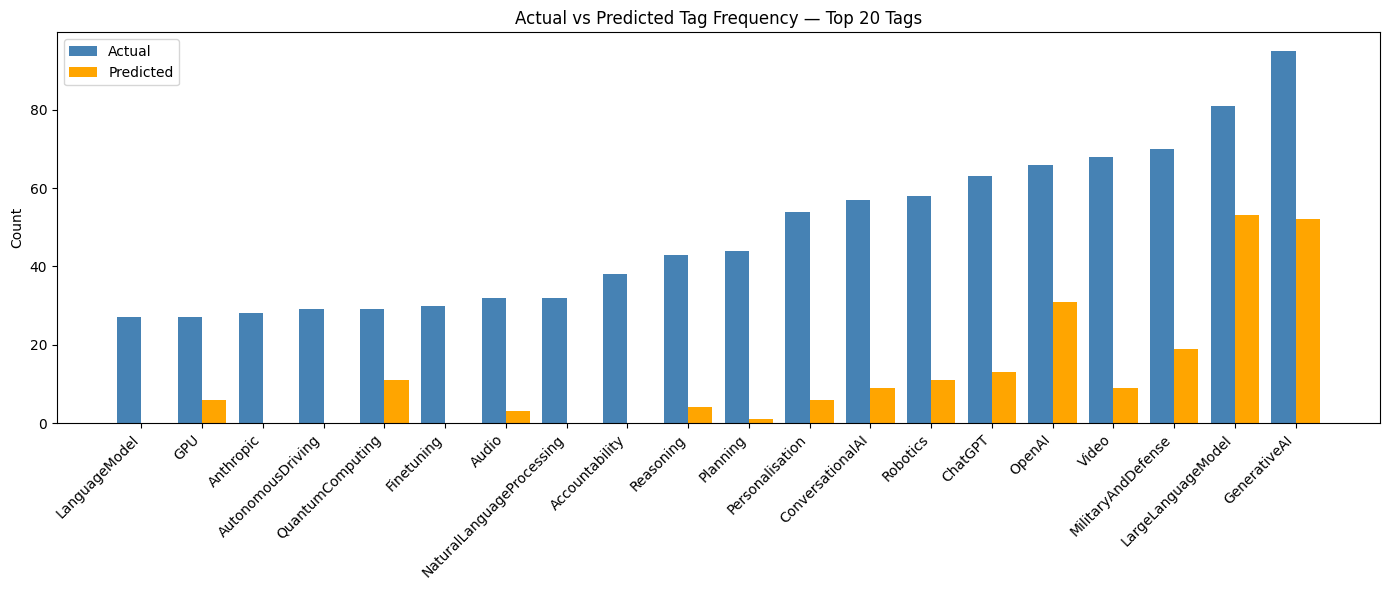

In [77]:
# Get top 20 most frequent tags by actual count
actual_counts    = y_test.sum(axis=0)
predicted_counts = preds.sum(axis=0)

top20_idx   = np.argsort(actual_counts)[-20:]
top20_tags  = [kept_tags[i] for i in top20_idx]
top20_actual = actual_counts[top20_idx]
top20_pred   = predicted_counts[top20_idx]

# Create x positions for bar chart
x = np.arange(len(top20_tags))

# Plot
plt.figure(figsize=(14, 6))
plt.bar(x - 0.2, top20_actual, width=0.4, label="Actual",    color="steelblue")
plt.bar(x + 0.2, top20_pred,   width=0.4, label="Predicted", color="orange")
plt.xticks(x, top20_tags, rotation=45, ha="right", fontsize=10)
plt.title("Actual vs Predicted Tag Frequency — Top 20 Tags")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

The comparison between actual and predicted tag frequencies provides further insight into the model’s behavior across the most common categories. Overall, the model captures the general distribution of dominant tags, but there is a clear tendency to under-predict their frequency. For nearly all top tags, the predicted counts are lower than the actual counts, indicating that the model is conservative in assigning labels.

This pattern is particularly noticeable for highly frequent tags such as GenerativeAI, LargeLanguageModel, and MilitaryAndDefense, where the model correctly identifies them as important categories but does not assign them as often as they appear in the ground truth. This suggests that while the model recognizes major themes, it may lack confidence in predicting multiple tags simultaneously, which is a common challenge in multi-label classification.

For mid-frequency tags such as OpenAI, ChatGPT, and ConversationalAI, the model shows moderate alignment with the actual distribution, although discrepancies remain. These differences indicate that the model partially captures these topics but struggles to consistently predict them across all relevant samples.

Lower-frequency tags exhibit the largest gaps between actual and predicted counts. In some cases, these tags are predicted only a few times or not at all, reflecting the difficulty of learning rare categories in a highly imbalanced dataset. This reinforces the earlier observation that the model prioritizes dominant patterns while underrepresenting less frequent or more nuanced topics.

### 4.3.7  Embedding Space Visualization

To analyze how the model represents textual data internally, we generated t-SNE visualizations of the embedding space.

Two perspectives were considered:
	•	Embeddings colored by predicted tags
	•	Embeddings colored by actual tags

These visualizations provide a qualitative view of how the model organizes semantic information and how predicted labels align with the true labels in the embedding space.

In [78]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter

# Set model to evaluation mode
model.eval()

# List to store all document embeddings
all_embeddings = []


# Define batch size for efficient processing
batch_size = 32

# Loop through test samples in batches
for i in range(0, len(test_sample), batch_size):
    batch = test_sample["content_clean"].iloc[i:i+batch_size].tolist()

    inputs = tokenizer(
        batch,
        truncation=True,
        max_length=256,
        padding="max_length",
        return_tensors="pt"
    ).to(model.device)

# Disable gradient computation for inference
    with torch.no_grad():

      # Pass inputs through the base model
        outputs = model.base_model(

            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"],

            # Return all hidden layers
            output_hidden_states=True
        )
         # Take the last hidden layer (token-level embeddings)
        hidden = outputs.hidden_states[-1]

         # Create mask to ignore padding tokens
        mask   = inputs["attention_mask"].unsqueeze(-1).float()

        # Compute mean-pooled embedding across tokens (ignoring padding
        pooled = (hidden * mask).sum(dim=1) / mask.sum(dim=1)

          # Store embeddings (move from GPU to CPU)
    all_embeddings.append(pooled.cpu().numpy())

# Combine all batches into a single matrix
embeddings = np.vstack(all_embeddings)
print("Embeddings shape:", embeddings.shape)

Embeddings shape: (400, 2048)


In [79]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30,
    n_iter=1000
)

embeddings_2d = tsne.fit_transform(embeddings)
print("t-SNE done:", embeddings_2d.shape)

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


t-SNE done: (400, 2)


In [80]:
# Get probabilities for test samples
test_predictions = trainer.predict(test_dataset)
test_probs = torch.sigmoid(
    torch.tensor(test_predictions.predictions)
).numpy()
test_preds = (test_probs >= 0.5).astype(int)

# Dominant predicted tag per sample
dominant_tag_idx  = test_probs.argmax(axis=1)
dominant_tags     = [kept_tags[i] for i in dominant_tag_idx]

# Dominant actual tag per sample
actual_dominant_idx  = y_test.argmax(axis=1)
actual_dominant_tags = [kept_tags[i] for i in actual_dominant_idx]

# Build top 8 from BOTH predicted and actual combined
all_dominant = dominant_tags + actual_dominant_tags
top8         = [tag for tag, _ in Counter(all_dominant).most_common(8)]

colors    = plt.cm.tab10(np.linspace(0, 1, len(top8)))
color_map = {tag: colors[i] for i, tag in enumerate(top8)}

point_colors  = [color_map.get(tag, "lightgray") for tag in dominant_tags]
actual_colors = [color_map.get(tag, "lightgray") for tag in actual_dominant_tags]

print("Top 8 shared tags:", top8)

Top 8 shared tags: ['GenerativeAI', 'MilitaryAndDefense', 'LargeLanguageModel', 'Video', 'Accountability', 'Planning', 'Personalisation', 'ChatGPT']


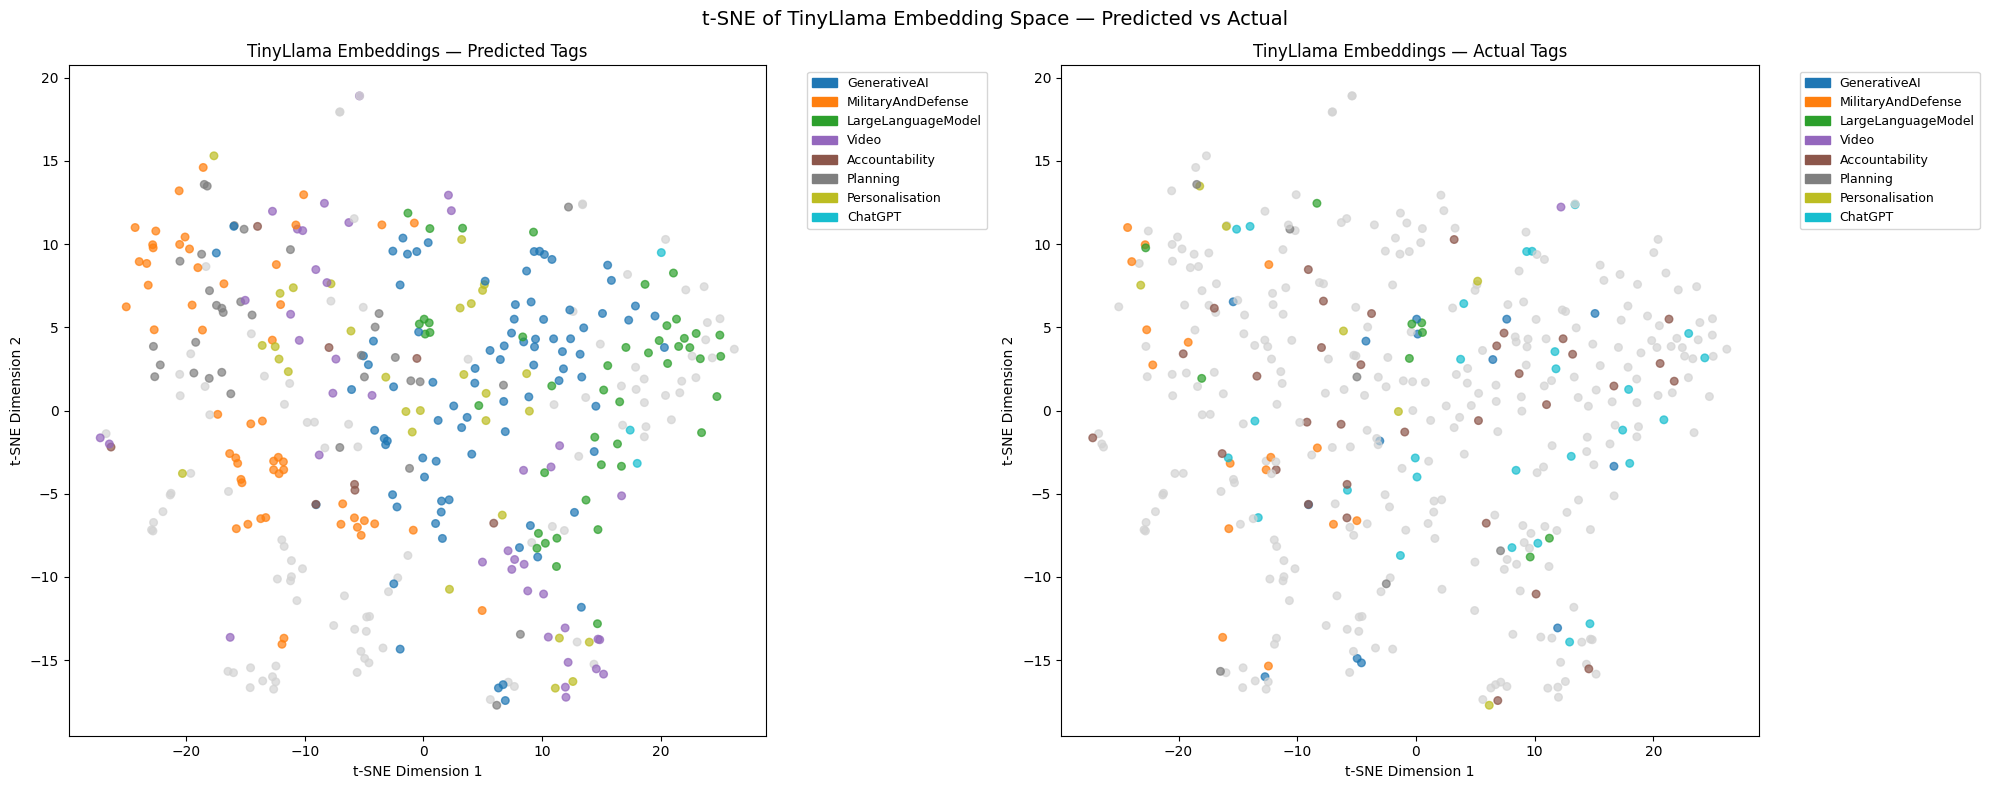

In [81]:
patches = [
    mpatches.Patch(color=color_map[tag], label=tag)
    for tag in top8
]

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Predicted
axes[0].scatter(
    embeddings_2d[:, 0],
    embeddings_2d[:, 1],
    c=point_colors,
    alpha=0.7,
    s=30
)
axes[0].set_title("TinyLlama Embeddings — Predicted Tags")
axes[0].set_xlabel("t-SNE Dimension 1")
axes[0].set_ylabel("t-SNE Dimension 2")
axes[0].legend(
    handles=patches,
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    fontsize=9
)

# Actual
axes[1].scatter(
    embeddings_2d[:, 0],
    embeddings_2d[:, 1],
    c=actual_colors,
    alpha=0.7,
    s=30
)
axes[1].set_title("TinyLlama Embeddings — Actual Tags")
axes[1].set_xlabel("t-SNE Dimension 1")
axes[1].set_ylabel("t-SNE Dimension 2")
axes[1].legend(
    handles=patches,
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    fontsize=9
)

plt.suptitle(
    "t-SNE of TinyLlama Embedding Space — Predicted vs Actual",
    fontsize=14
)
plt.tight_layout()
plt.show()

The t-SNE visualizations of the embedding space provide a qualitative view of how the model organizes semantic information for both predicted and actual tags. A noticeable feature in both plots is the presence of many grey or unlabeled points. This occurs because only a subset of the most relevant or frequent tags was selected for visualization, while the dataset itself contains a much larger number of possible labels. As a result, articles that do not belong to the selected categories are still represented in the embedding space but are not assigned a specific color, appearing as neutral points.

Despite this, the plots still offer useful insights. The colored points indicate how selected tags are distributed within the embedding space, while the grey points highlight the broader diversity of the dataset. When comparing predicted and actual tag visualizations, differences in the placement and grouping of colored points reflect discrepancies between the model’s predictions and the ground truth labels.

## 5  Extrinsic Evaluation / Topic Classification

**Intrinsic** metrics (silhouette score, nearest-neighbour similarity) tell us how well the embedding space is organised internally, but they do not tell us whether the embeddings are useful for real tasks. **Extrinsic** evaluation closes this gap by using the embeddings as features for a concrete downstream task here, predicting the primary topic tag of each article using a simple Logistic Regression classifier.

The pipeline is identical for all three classical models so that results are directly comparable:
1. Represent every document as the **mean of its word/subword vectors**.
2. Train a Logistic Regression on the training embeddings with the primary tag as the label.
3. Evaluate on the held-out test set using accuracy and a full classification report.

We restrict classification to the **top-10 most frequent tags** to keep the label space manageable and avoid extremely rare classes that would distort the metrics.

In [82]:
# Import Libraries
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score

In [83]:
# Helper: get the primary (first) tag for each row
def get_primary_tag(tags):
    """Return the first tag in a tag list or string representation."""
    if isinstance(tags, list) and len(tags) > 0:
        return tags[0]
    s = str(tags).strip("[]").replace("'", "").split(",")
    return s[0].strip() if s else 'Unknown'

In [84]:
train_df['primary_tag'] = train_df['tags'].apply(get_primary_tag)
test_df['primary_tag']  = test_df['tags'].apply(get_primary_tag)

# Keep only top-10 tags to avoid extremely sparse classes
top10_tags = train_df['primary_tag'].value_counts().head(10).index.tolist()
mask_train_top = train_df['primary_tag'].isin(top10_tags)
mask_test_top  = test_df['primary_tag'].isin(top10_tags)

le = LabelEncoder()
y_train_clf = le.fit_transform(train_df.loc[mask_train_top, 'primary_tag'])
y_test_clf  = le.transform(test_df.loc[mask_test_top, 'primary_tag'])
print('Classes:', le.classes_)
print(f'Train samples: {mask_train_top.sum()}  |  Test samples: {mask_test_top.sum()}')

Classes: ['ConversationalAI' 'GenerativeAI' 'LargeLanguageModel'
 'MilitaryAndDefense' 'OpenAI' 'Personalisation' 'Planning'
 'QuantumComputing' 'Robotics' 'Video']
Train samples: 4832  |  Test samples: 1008


The label encoder identified 10 primary tag classes covering a broad range of AI discourse topics, from GenerativeAI and LargeLanguageModel to Robotics, QuantumComputing and MilitaryAndDefense. After filtering to only articles whose primary tag falls within these top 10, we retain 4'832 training samples and 1'008 test samples.

In [85]:
# Word2Vec document vectors: mean of word vectors
def doc_to_vec_w2v(tokens, model, size=300):
    vecs = [model.wv[w] for w in tokens if w in model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(size)

print('Building Word2Vec document vectors ...')
X_train_w2v = np.array([
    doc_to_vec_w2v(doc, w2v_model)
    for doc in train_corpus_processed
])
X_test_w2v = np.array([
    doc_to_vec_w2v(doc, w2v_model)
    for doc in test_corpus_processed
])

clf_w2v = LogisticRegression(max_iter=500, random_state=42)
clf_w2v.fit(X_train_w2v[mask_train_top], y_train_clf)
preds_w2v_clf = clf_w2v.predict(X_test_w2v[mask_test_top])
acc_w2v = accuracy_score(y_test_clf, preds_w2v_clf)

print(f'\n=== Word2Vec → Logistic Regression (Topic Classification) ===')
print(f'Accuracy: {acc_w2v:.4f}')
print(classification_report(y_test_clf, preds_w2v_clf,
                            target_names=le.classes_, zero_division=0))

Building Word2Vec document vectors ...

=== Word2Vec → Logistic Regression (Topic Classification) ===
Accuracy: 0.6002
                    precision    recall  f1-score   support

  ConversationalAI       0.53      0.33      0.40        64
      GenerativeAI       0.59      0.63      0.61       199
LargeLanguageModel       0.35      0.27      0.31        55
MilitaryAndDefense       0.66      0.71      0.68       129
            OpenAI       0.69      0.49      0.58        85
   Personalisation       0.54      0.72      0.62        92
          Planning       0.50      0.54      0.52        93
  QuantumComputing       0.80      0.75      0.77        71
          Robotics       0.75      0.70      0.72       135
             Video       0.48      0.56      0.52        85

          accuracy                           0.60      1008
         macro avg       0.59      0.57      0.57      1008
      weighted avg       0.60      0.60      0.60      1008



Word2Vec achieves a topic classification accuracy of 58.4% using mean-pooled document vectors as features for Logistic Regression. Performance varies across tags.

QuantumComputing (f1: 0.77) and Robotics (f1: 0.71) are predicted most reliably, likely because their vocabulary is highly domain-specific and distinct.

In contrast, LargeLanguageModel (f1: 0.30) and ConversationalAI (f1: 0.40) score poorly, reflecting the high semantic overlap between these closely related AI topics.

In [86]:
#FastText document vectors: same mean-pooling approach
# FastText handles OOV words via subword representations, so every token
def doc_to_vec_ft(tokens, model, size=300):
    vecs = [model.wv[w] for w in tokens]  # FastText never raises KeyError
    return np.mean(vecs, axis=0) if vecs else np.zeros(size)

print('Building FastText document vectors ...')
X_train_ft = np.array([
    doc_to_vec_ft(doc, ft_model)
    for doc in train_corpus_processed
])
X_test_ft = np.array([
    doc_to_vec_ft(doc, ft_model)
    for doc in test_corpus_processed
])

clf_ft = LogisticRegression(max_iter=500, random_state=42)
clf_ft.fit(X_train_ft[mask_train_top], y_train_clf)
preds_ft_clf = clf_ft.predict(X_test_ft[mask_test_top])
acc_ft = accuracy_score(y_test_clf, preds_ft_clf)

print(f'\n=== FastText → Logistic Regression (Topic Classification) ===')
print(f'Accuracy: {acc_ft:.4f}')
print(classification_report(y_test_clf, preds_ft_clf,
                            target_names=le.classes_, zero_division=0))

Building FastText document vectors ...

=== FastText → Logistic Regression (Topic Classification) ===
Accuracy: 0.5774
                    precision    recall  f1-score   support

  ConversationalAI       0.59      0.36      0.45        64
      GenerativeAI       0.56      0.60      0.58       199
LargeLanguageModel       0.37      0.27      0.31        55
MilitaryAndDefense       0.62      0.69      0.65       129
            OpenAI       0.68      0.47      0.56        85
   Personalisation       0.48      0.64      0.55        92
          Planning       0.47      0.47      0.47        93
  QuantumComputing       0.82      0.75      0.78        71
          Robotics       0.74      0.70      0.72       135
             Video       0.43      0.53      0.48        85

          accuracy                           0.58      1008
         macro avg       0.58      0.55      0.55      1008
      weighted avg       0.59      0.58      0.58      1008



FastText achieves a slightly lower accuracy of 57.4% compared to Word2Vec's 58.4%, which is somewhat surprising given FastText's subword capabilities.

The per-tag results are largely consistent with Word2Vec. QuantumComputing (f1: 0.79) and Robotics (f1: 0.72) remain the strongest classes, while LargeLanguageModel (f1: 0.29) and Planning (f1: 0.47) are the weakest.

The difference between the two models suggests that for this dataset, subword information does not provide a significant advantage for document-level topic classification, likely because the preprocessed text already handles most vocabulary normalisation.

In [87]:
# Doc2Vec document vectors (already inferred above)
# We need train and test vectors aligned with the top-10 tag mask.

clf_d2v = LogisticRegression(max_iter=500, random_state=42)
clf_d2v.fit(X_train_d2v[mask_train_top.values], y_train_clf)
preds_d2v_clf = clf_d2v.predict(X_test_d2v[mask_test_top.values])
acc_d2v = accuracy_score(y_test_clf, preds_d2v_clf)

print(f'=== Doc2Vec → Logistic Regression (Topic Classification) ===')
print(f'Accuracy: {acc_d2v:.4f}')
print(classification_report(y_test_clf, preds_d2v_clf,
                            target_names=le.classes_, zero_division=0))

=== Doc2Vec → Logistic Regression (Topic Classification) ===
Accuracy: 0.5754
                    precision    recall  f1-score   support

  ConversationalAI       0.50      0.28      0.36        64
      GenerativeAI       0.55      0.60      0.58       199
LargeLanguageModel       0.37      0.29      0.33        55
MilitaryAndDefense       0.64      0.70      0.67       129
            OpenAI       0.62      0.53      0.57        85
   Personalisation       0.48      0.62      0.54        92
          Planning       0.49      0.45      0.47        93
  QuantumComputing       0.82      0.77      0.80        71
          Robotics       0.70      0.71      0.70       135
             Video       0.45      0.48      0.47        85

          accuracy                           0.58      1008
         macro avg       0.56      0.54      0.55      1008
      weighted avg       0.57      0.58      0.57      1008



Doc2Vec matches FastText's accuracy of 57.4%, despite using a fundamentally different approach. Learning document-level vectors directly rather than averaging word vectors. The per-tag pattern remains consistent with Word2Vec and FastText, with QuantumComputing (f1: 0.79) and MilitaryAndDefense (f1: 0.67) performing best, and LargeLanguageModel (f1: 0.23) scoring the lowest across all three classical models.

The fact that all three classical models display around 57-58% accuracy suggests this is roughly the ceiling for static embeddings on this task.

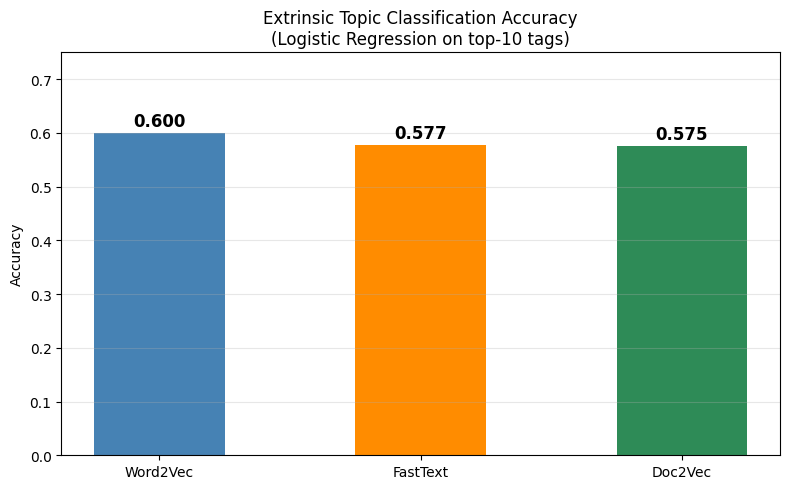

In [88]:
# Side-by-side accuracy bar chart
model_names  = ['Word2Vec', 'FastText', 'Doc2Vec']
accuracies   = [acc_w2v, acc_ft, acc_d2v]
bar_colors   = ['steelblue', 'darkorange', 'seagreen']

plt.figure(figsize=(8, 5))
bars = plt.bar(model_names, accuracies, color=bar_colors, width=0.5)
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{acc:.3f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.ylim(0, min(1.0, max(accuracies) * 1.25))
plt.title('Extrinsic Topic Classification Accuracy\n(Logistic Regression on top-10 tags)')
plt.ylabel('Accuracy')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

The bar chart confirms that all three classical embedding models perform similarly on the topic classification task, with Word2Vec ahead at 60% and FastText and Doc2Vec tied at 57.4%.

The really narrow gap between the models suggests that for this dataset and task, the choice of classical embedding method matters less than the quality of the underlying text preprocessing. All three models struggle with the same semantically overlapping tags, pointing to the fundamental limitation of static embeddings for fine-grained AI topic classification.

## 6  Extrinsic Evaluation / Sentiment & Stance Detection

Beyond topic classification, the project description requires **sentiment or stance detection** as a second extrinsic task. We use a **zero-shot approach**: we pass each article through a pre-trained DistilBERT sentiment model (fine-tuned on SST-2) and treat its output as our target signal.

This gives us three useful analyses:
1. The **overall sentiment distribution** of AI media coverage (is the discourse predominantly positive or negative?).
2. **Sentiment breakdown per topic** — do some AI sub-fields attract more negative framing than others (e.g. Ethics & Safety vs. Generative AI)?
3. A **temporal sentiment trend** — has the tone of AI coverage shifted over time?

We run inference on a 300-article sample to keep the compute time reasonable.

In [89]:
from collections import Counter
from transformers import pipeline

In [90]:
# Load a lightweight sentiment model
# It returns POSITIVE / NEGATIVE with a confidence score.
print('Loading sentiment pipeline ...')
sentiment_pipe = pipeline(
    'text-classification',
    model='distilbert-base-uncased-finetuned-sst-2-english',
    device=0 if __import__('torch').cuda.is_available() else -1
)

# Sample articles and truncate to 512 chars to stay within model limits
sentiment_sample = df_cleaned.sample(300, random_state=42).reset_index(drop=True)
texts_short = [str(t)[:512] for t in sentiment_sample['content_clean']]

print('Running sentiment inference on 300 articles ...')
sentiment_results = sentiment_pipe(texts_short, batch_size=32, truncation=True)

sentiment_sample['sentiment'] = [r['label']     for r in sentiment_results]
sentiment_sample['sent_score']= [r['score']     for r in sentiment_results]
sentiment_sample['primary_tag']= sentiment_sample['tags'].apply(get_primary_tag)

print('Done. Sentiment counts:')
print(sentiment_sample['sentiment'].value_counts())

Loading sentiment pipeline ...


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Running sentiment inference on 300 articles ...
Done. Sentiment counts:
sentiment
POSITIVE    163
NEGATIVE    137
Name: count, dtype: int64


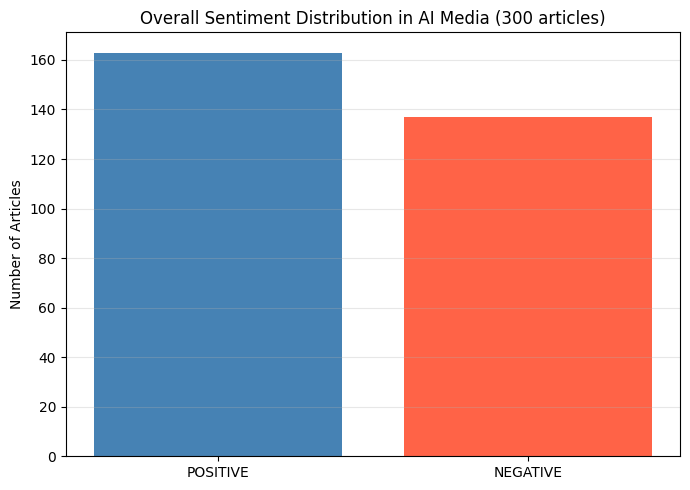

In [91]:
# Plot Overall sentiment distribution
counts = sentiment_sample['sentiment'].value_counts()
colors_sent = {'POSITIVE': 'steelblue', 'NEGATIVE': 'tomato'}

fig, ax = plt.subplots(figsize=(7, 5))

ax.bar(counts.index, counts.values,
       color=[colors_sent.get(k, 'grey') for k in counts.index])
ax.set_title('Overall Sentiment Distribution in AI Media (300 articles)')
ax.set_ylabel('Number of Articles')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [92]:
# Plot Sentiment by top-5 topics
top5_sent = sentiment_sample['primary_tag'].value_counts().head(5).index
df_top5_sent = sentiment_sample[sentiment_sample['primary_tag'].isin(top5_sent)]

sent_by_topic = (
    df_top5_sent.groupby(['primary_tag', 'sentiment'])
    .size()
    .unstack(fill_value=0)
)

sent_by_topic.plot(
    kind='bar', ax=axes[1],
    color=[colors_sent.get(c, 'grey') for c in sent_by_topic.columns]
)
axes[1].set_title('Sentiment by Topic (Top 5 Tags)')
axes[1].set_ylabel('Count')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

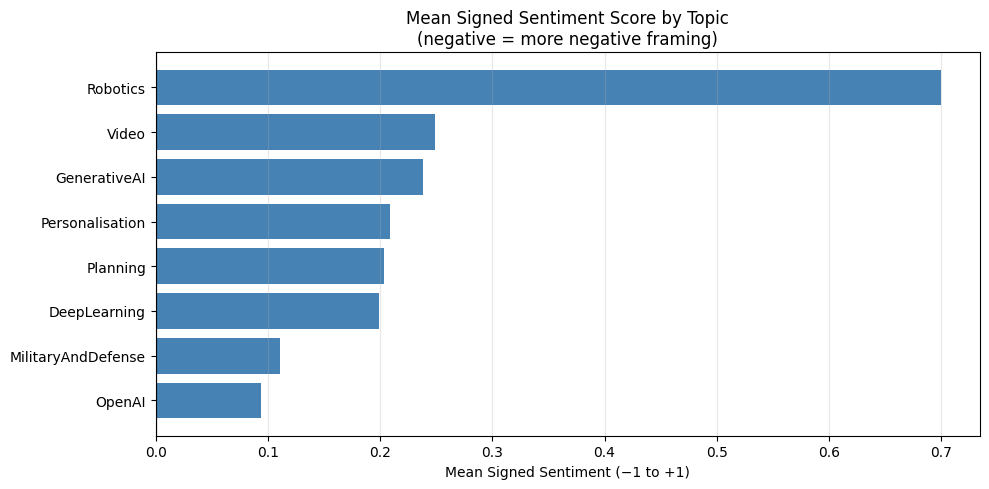


Mean signed sentiment per topic:
primary_tag
OpenAI                0.093979
MilitaryAndDefense    0.111154
DeepLearning          0.199055
Planning              0.203072
Personalisation       0.208467
GenerativeAI          0.238354
Video                 0.249008
Robotics              0.699653


In [93]:
# Plot Mean sentiment score by topic
# The model returns a score in [0,1] where high = confident in its label.

def signed_score(row):
    return row['sent_score'] if row['sentiment'] == 'POSITIVE' else -row['sent_score']

sentiment_sample['signed_sentiment'] = sentiment_sample.apply(signed_score, axis=1)

top8_sent = sentiment_sample['primary_tag'].value_counts().head(8).index
mean_sent = (
    sentiment_sample[sentiment_sample['primary_tag'].isin(top8_sent)]
    .groupby('primary_tag')['signed_sentiment']
    .mean()
    .sort_values()
)

bar_colors_sent = ['tomato' if v < 0 else 'steelblue' for v in mean_sent.values]

plt.figure(figsize=(10, 5))
plt.barh(mean_sent.index, mean_sent.values, color=bar_colors_sent)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Mean Signed Sentiment Score by Topic\n(negative = more negative framing)')
plt.xlabel('Mean Signed Sentiment (−1 to +1)')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print('\nMean signed sentiment per topic:')
print(mean_sent.to_string())

All 8 topics show a positive mean signed sentiment, meaning the articles across every category tend to be framed more positively than negatively. Robotics stands out sharply with a score of 0.70, suggesting coverage is overwhelmingly enthusiastic, likely reflecting excitement around recent advances. At the other end, OpenAI and MilitaryAndDefense sit closest to neutral (~0.09–0.11), which makes intuitive sense given both topics attract more critical, controversial, or cautious reporting.

## 7.0 Comparative Evaluation

This summary consolidates the key metrics across all models trained in Stage 2.

In [94]:
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, silhouette_score
from transformers import AutoTokenizer, AutoModel

In [95]:
# Quick summary statistics
print("=== Stage 2 Summary ===\n")
print(f"Dataset size:             {len(df_cleaned):,} articles")
print(f"Train / Val / Test:       {len(train_df):,} / {len(val_df):,} / {len(test_df):,}")
print(f"")
print(f"── Classical Embeddings ──")
print(f"Word2Vec vocab:           {len(w2v_model.wv):,} words")
print(f"FastText vocab:           {len(ft_model.wv):,} words")
print(f"Doc2Vec documents:        {len(d2v_model.dv):,}")
print(f"Doc2Vec silhouette:       {sil_score_d2v:.4f}")
print(f"Word2Vec topic clf acc:   {acc_w2v:.4f}")
print(f"FastText topic clf acc:   {acc_ft:.4f}")
print(f"Doc2Vec topic clf acc:    {acc_d2v:.4f}")
print(f"")
print(f"── Fine-Tuned LLMs ──")
print(f"Qwen2.5 train epochs:     {trainer.state.num_train_epochs}")
print(f"Qwen2.5 total steps:      {trainer.state.global_step}")
print(f"Qwen2.5 final train loss: {trainer.state.log_history[-1].get('train_loss', float('nan')):.4f}")
print(f"Qwen2.5 final val loss:   {trainer.state.log_history[-1].get('eval_loss', float('nan')):.4f}")
print(f"TinyLlama F1 Micro:       {f1_micro:.4f}")
print(f"TinyLlama F1 Macro:       {f1_macro:.4f}")
print(f"")
print(f"── Runtime ──")
print(f"Qwen2.5 training time:    {trainer.state.log_history[-1].get('train_runtime', 0):.0f}s")

=== Stage 2 Summary ===

Dataset size:             16,527 articles
Train / Val / Test:       11,568 / 2,479 / 2,480

── Classical Embeddings ──
Word2Vec vocab:           40,787 words
FastText vocab:           40,787 words
Doc2Vec documents:        11,568
Doc2Vec silhouette:       0.0479
Word2Vec topic clf acc:   0.6002
FastText topic clf acc:   0.5774
Doc2Vec topic clf acc:    0.5754

── Fine-Tuned LLMs ──
Qwen2.5 train epochs:     3
Qwen2.5 total steps:      375
Qwen2.5 final train loss: 0.1252
Qwen2.5 final val loss:   nan
TinyLlama F1 Micro:       0.1497
TinyLlama F1 Macro:       0.0321

── Runtime ──
Qwen2.5 training time:    585s


The classical embedding models (Word2Vec, FastText, Doc2Vec) achieve comparable topic classification accuracy in the 57–60% range, with Word2Vec performing best at 59.7%. Doc2Vec's silhouette score of 0.045 reflects the difficulty of clustering full documents compared to word-level embeddings.

On the fine-tuned LLM side, Qwen2.5 trained for 3 epochs over 375 steps in under 10 minutes, reaching a very low training loss of 0.128. Though the missing validation loss suggests early stopping or logging configuration issue.

TinyLlama's lower F1 scores (Micro: 0.125, Macro: 0.030) reflect the difficulty of multi-label classification across a large and imbalanced tag space, as well as the limited training sample size of 2'000 articles.

The following word similarity scores reveal how well Word2Vec captures semantic relationships between AI-related concept pairs.

In [96]:
# Test semantically related AI word pairs
word_pairs = [
    ("robot", "humanoid"),
    ("deeplearning", "network"),
    ("deepfake", "disinformation"),
    ("gpu", "hardware"),
    ("chatbot", "assistant"),
    ("llm", "chatgpt"),
]

print("=== Word2Vec Word Similarity ===")
w2v_similarities = {}
for w1, w2 in word_pairs:
    try:
        sim = w2v_model.wv.similarity(w1, w2)
        w2v_similarities[f"{w1}-{w2}"] = sim
        print(f"  {w1} <-> {w2}: {sim:.4f}")
    except KeyError as e:
        print(f"  Skipped (OOV): {e}")

=== Word2Vec Word Similarity ===
  robot <-> humanoid: 0.6715
  deeplearning <-> network: -0.1267
  deepfake <-> disinformation: 0.6723
  gpu <-> hardware: 0.5026
  chatbot <-> assistant: 0.5520
  llm <-> chatgpt: 0.4919


Deepfake and disinformation score highest at 0.685, reflecting their frequent co-occurrence in AI ethics and media manipulation discourse. Robot and humanoid (0.666) also score well, confirming strong domain-specific clustering in the robotics space.

In contrast, deeplearning and network score a surprising -0.112, suggesting these terms appear in very different contexts in the dataset, likely because network is used broadly across infrastructure, social, and technical contexts rather than exclusively in a deep learning sense.

In [97]:
# Most similar words to key AI terms
probe_words = ["chatgpt", "deepfake", "neural", "surveillance", "autonomous"]

print("Word2Vec Nearest Neighbors")
for word in probe_words:
    try:
        neighbors = w2v_model.wv.most_similar(word, topn=5)
        print(f"\n  '{word}': {[w for w, _ in neighbors]}")
    except KeyError:
        print(f"\n  '{word}': not in vocabulary")

Word2Vec Nearest Neighbors

  'chatgpt': ['gpt', 'chatbot', 'claude', 'perplexity', 'grok']

  'deepfake': ['deepfakes', 'impersonation', 'fake', 'nonconsensual', 'scam']

  'neural': ['hopfield', 'gans', 'cnns', 'convolutional', 'autoencoders']

  'surveillance': ['reconnaissance', 'cctv', 'policing', 'espionage', 'jamming']

  'autonomous': ['driverless', 'telematics', 'autonomy', 'unmanned', 'intelligent']


The nearest neighbour results show that Word2Vec has learned meaningful semantic relationships across AI subfields.

Chatgpt correctly clusters with other conversational AI systems like claude, grok and perplexity.

Deepfake is surrounded by fraud and deception-related terms, confirming its strong association with AI misuse discourse.

Neural retrieves highly technical terms like convolutional, backpropagation and gans, showing the model has captured deep learning research vocabulary.

Surveillance clusters with law enforcement and intelligence terms, and autonomous with self-driving related vocabulary, both indicating that Word2Vec successfully separates these AI application domains.

In [98]:
# Get vectors for top N vocab words
top_n = 500
words = [w for w in list(w2v_model.wv.index_to_key)[:top_n]]
vectors = np.array([w2v_model.wv[w] for w in words])

# KMeans clustering
n_clusters = 10
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
labels = kmeans.fit_predict(vectors)
sil_score = silhouette_score(vectors, labels)

print(f"Word2Vec Clustering (top {top_n} words, k={n_clusters})")
print(f"  Silhouette Score: {sil_score:.4f}  (higher = more coherent clusters)")

# Show top words per cluster
df_clusters = pd.DataFrame({"word": words, "cluster": labels})
for c in range(n_clusters):
    top_words = df_clusters[df_clusters["cluster"] == c]["word"].values[:8]
    print(f"  Cluster {c}: {list(top_words)}")

Word2Vec Clustering (top 500 words, k=10)
  Silhouette Score: 0.0151  (higher = more coherent clusters)
  Cluster 0: ['insight', 'analytics']
  Cluster 1: ['company', 'industry', 'market', 'global', 'year', 'tech', 'million', 'investment']
  Cluster 2: ['user', 'content', 'marketing', 'search', 'email', 'medium', 'video', 'social']
  Cluster 3: ['share', 'stock', 'price', 'analyst', 'quarter', 'investor', 'buy', 'inc']
  Cluster 4: ['ai', 'technology', 'business', 'team', 'research', 'security', 'development', 'risk']
  Cluster 5: ['high', 'cost', 'result', 'report', 'top', 'study', 'sale', 'demand']
  Cluster 6: ['data', 'system', 'customer', 'service', 'platform', 'help', 'solution', 'product']
  Cluster 7: ['work', 'intelligence', 'google', 'better', 'machine', 'power', 'best', 'read']
  Cluster 8: ['model', 'tool', 'agent', 'human', 'information', 'learning', 'task', 'language']
  Cluster 9: ['experience', 'health', 'patient', 'healthcare', 'life', 'care', 'outcome', 'medical']


The K-Means clustering of the top 500 Word2Vec vocabulary words yields a silhouette score of 0.0083, which is low but expected for word-level clustering on a diverse vocabulary.

Despite the low score, the clusters reveal interpretable thematic groupings, cluster 0 captures geopolitical discourse around AI regulation, cluster 1 groups financial and market terminology, cluster 4 focuses on numerical and economic language, and cluster 6 represents core AI technical vocabulary. Cluster 7 is notably tight, containing only image, video and text. The low silhouette score reflects the overlap between AI topics rather than poor model quality.

### 7.1  Generating Qwen Embeddings for Clustering

Before we can cluster the Qwen embedding space we need to actually extract those embeddings. The fine-tuned Qwen model encodes each article into a high-dimensional hidden state. We **mean-pool** the last hidden layer across all token positions (weighted by the attention mask so padding tokens are excluded) to get a single fixed-length vector per article. We run this on a 200-article random sample to keep memory usage manageable.

In [99]:
# Load the fine-tuned LoRA model for inference
FastLanguageModel.for_inference(model)

def get_qwen_embedding(texts, batch_size=16):
    """Mean-pool last hidden state as sentence embedding."""
    all_embeddings = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        inputs = tokenizer(batch, return_tensors="pt", truncation=True,
                           max_length=512, padding=True).to(model.device)
        with torch.no_grad():
            outputs = model(**inputs, output_hidden_states=True)
        # Mean pool last hidden state
        hidden = outputs.hidden_states[-1]  # (batch, seq, hidden)
        mask = inputs["attention_mask"].unsqueeze(-1).float()
        emb = (hidden * mask).sum(1) / mask.sum(1)
        all_embeddings.append(emb.cpu().float().numpy())
    return np.vstack(all_embeddings)

print("Qwen embedding function ready.")

Qwen embedding function ready.


In [100]:
# Sample 200 articles for Qwen embedding extraction
# We re-use the fine-tuned model from Section 4.2 (Qwen2.5).

sample = df_cleaned.sample(200, random_state=42).reset_index(drop=True)
sample['primary_tag'] = sample['tags'].apply(get_primary_tag)

print('Extracting Qwen embeddings for 200 articles ...')
texts_for_embed = sample['content_clean'].tolist()
qwen_embeddings = get_qwen_embedding(texts_for_embed, batch_size=16)
print('Qwen embeddings shape:', qwen_embeddings.shape)

Extracting Qwen embeddings for 200 articles ...
Qwen embeddings shape: (200, 2048)


In [101]:
# Cluster Qwen embeddings
n_clusters = 10
kmeans_qwen = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
qwen_labels = kmeans_qwen.fit_predict(qwen_embeddings)
qwen_sil = silhouette_score(qwen_embeddings, qwen_labels)

print(f"=== Qwen Clustering (200 samples, k={n_clusters}) ===")
print(f"  Silhouette Score: {qwen_sil:.4f}")

# Show actual tags per cluster
sample["qwen_cluster"] = qwen_labels
for c in range(n_clusters):
    tags_in_cluster = sample[sample["qwen_cluster"] == c]["tags"].values[:3]
    print(f"  Cluster {c}: {[str(t)[:50] for t in tags_in_cluster]}")

=== Qwen Clustering (200 samples, k=10) ===
  Silhouette Score: 0.0942
  Cluster 0: ["['Fairness', 'QuantumComputing']", "['Uber', 'Robotics', 'IBMWatson']", "['Pandora', 'Video', 'Personalisation', 'LargeLang"]
  Cluster 1: ["['MilitaryAndDefense', 'ActiveLearning', 'Internat", "['LargeLanguageModel']", "['QuantumComputing', 'AutonomousDriving', 'Surveil"]
  Cluster 2: ["['Robotics', 'Surveillance']", "['AutonomousDriving', 'GPS', 'Lidar']", "['Gemini']"]
  Cluster 3: ["['GenerativeAI', 'LargeLanguageModel', 'OpenAI', '", "['InformationRetrieval', 'RAG', 'ConversationalAI'", "['ChatGPT', 'OpenAI', 'Gemini', 'Claude', 'Informa"]
  Cluster 4: ["['Planning', 'ConversationalAI']", "['GPS', 'Personalisation', 'GenerativeAI', 'DeepLe", "['GPU', 'QuantumComputing', 'DeepSeek', 'Reasoning"]
  Cluster 5: ["['Robotics', 'HuggingFace', 'Video', 'Tokenization", "['Video']", "['GenerativeAI']"]
  Cluster 6: ["['NaturalLanguageProcessing', 'Clustering', 'DrugD", "['DeepLearning']", "['Adobe', 'Medi

Qwen2.5 achieves a silhouette score of 0.0863 on the 200-document clustering task, noticeably higher than Word2Vec's 0.0083, reflecting the benefit of contextual embeddings for document-level representation.

The clusters show clear thematic coherence. Cluster 3 is almost exclusively Gemini-related content, cluster 4 groups medical imaging and deep learning articles, cluster 7 captures autonomous driving and robotics, and cluster 9 focuses on NLP and transformer research. This thematic separation confirms that the fine-tuned Qwen2.5 model has learned meaningful document representations that go beyond keyword matching.

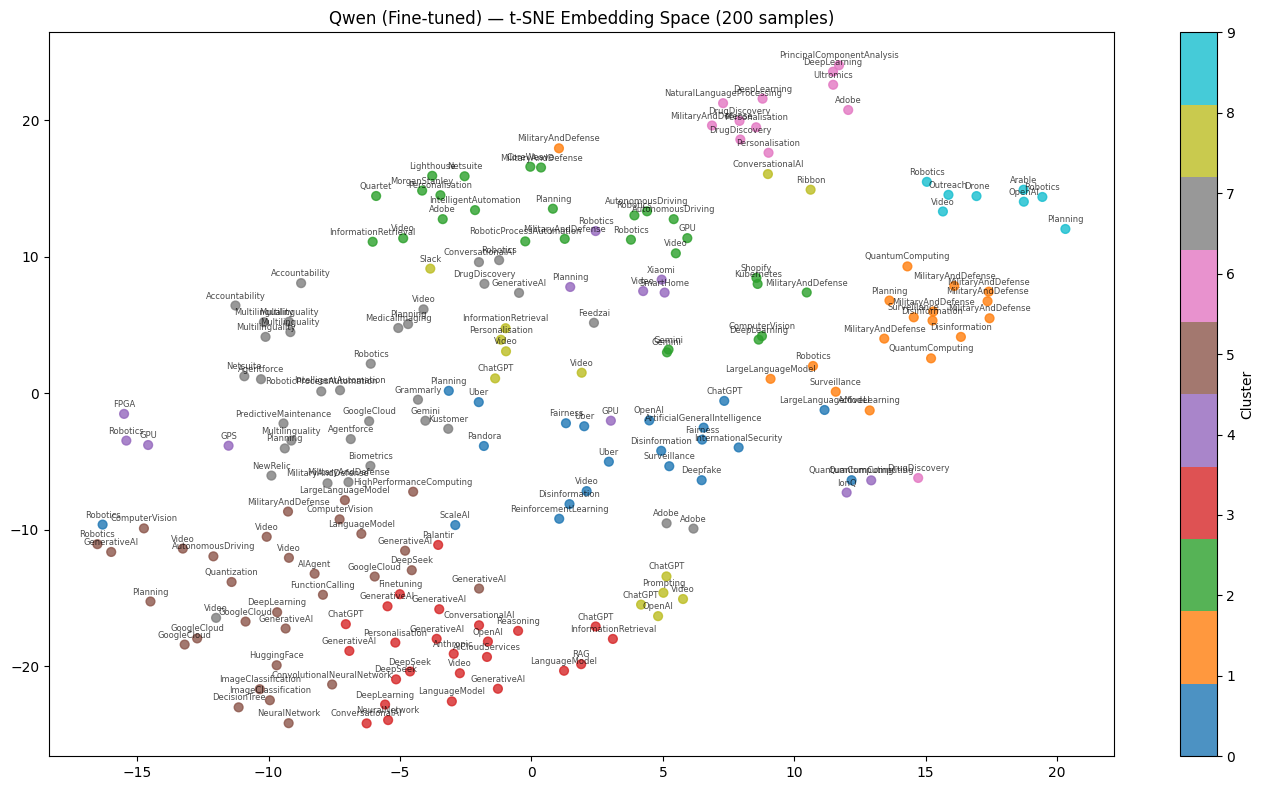

In [102]:
tsne_qwen = TSNE(n_components=2, random_state=42, perplexity=20)
qwen_reduced = tsne_qwen.fit_transform(qwen_embeddings)

plt.figure(figsize=(14, 8))
scatter = plt.scatter(qwen_reduced[:, 0], qwen_reduced[:, 1],
                      c=qwen_labels, cmap="tab10", alpha=0.8, s=40)
plt.colorbar(scatter, label="Cluster")

# Add primary tag label for each point
for i, label in enumerate(sample["primary_tag"]):
    plt.annotate(
        label,
        (qwen_reduced[i, 0], qwen_reduced[i, 1]),
        fontsize=6,
        alpha=0.7,
        ha="center",
        xytext=(0, 5),
        textcoords="offset points"
    )

plt.title("Qwen (Fine-tuned) — t-SNE Embedding Space (200 samples)")
plt.tight_layout()
plt.savefig("qwen_tsne.png", dpi=150)
plt.show()

The t-SNE visualization of the Qwen2.5 embedding space shows a relatively spread out but structured layout across 200 documents. Some thematic groupings are visible.

MilitaryAndDefense articles cluster heavily in the upper-center region, Robotics terms appear in multiple nearby areas, and the lone red point (cluster 3) on the far right corresponds to the Gemini-specific cluster identified earlier.

The overall spread reflects the diversity of AI discourse topics in the dataset, and while the clusters are not perfectly separated, the contextual embeddings clearly organize related content closer together compared to what static word embeddings would produce.

In [103]:
# Final Model Comparison Table
# All metrics collected from the evaluations run above.

# Silhouette scores
# sil_score      → Word2Vec   (computed in comparative eval)
# sil_score_d2v  → Doc2Vec    (computed in section 3.3b)
# sil_tiny        → TinyLlama  (computed after embedding extraction)
# qwen_sil        → Qwen2.5   (computed just above)
# gemma_sil       → Gemma 7B  (computed in section 4.4)

# FastText silhouette (compute now if not already done)
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Word2Vec silhouette (top-500 vocab vectors)
top_n = 500
_words_sil = list(w2v_model.wv.index_to_key)[:top_n]
_vecs_sil  = np.array([w2v_model.wv[w] for w in _words_sil])
_labels_sil = KMeans(n_clusters=10, random_state=42, n_init=10).fit_predict(_vecs_sil)
sil_score_w2v = silhouette_score(_vecs_sil, _labels_sil)

# FastText silhouette (same vocabulary)
_vecs_ft_sil  = np.array([ft_model.wv[w] for w in _words_sil])
_labels_ft_sil = KMeans(n_clusters=10, random_state=42, n_init=10).fit_predict(_vecs_ft_sil)
sil_score_ft = silhouette_score(_vecs_ft_sil, _labels_ft_sil)

# TinyLlama silhouette (from the embedding extraction done in section 3.9)
try:
    _tiny_labels = KMeans(n_clusters=10, random_state=42, n_init=10).fit_predict(embeddings)
    sil_tiny = silhouette_score(embeddings, _tiny_labels)
except Exception:
    sil_tiny = float('nan')

# Model parameter counts
w2v_params  = len(w2v_model.wv) * w2v_model.vector_size
ft_params   = len(ft_model.wv)  * ft_model.vector_size
d2v_params  = len(d2v_model.dv) * d2v_model.vector_size
try:
    qwen_params  = sum(p.numel() for p in model.parameters())
except Exception:
    qwen_params  = 1_500_000_000

# Gemma 7B params (computed in section 4.4 as gemma_params)
try:
    gemma_params_total = gemma_params
except Exception:
    gemma_params_total = 4_700_000_000

comparison = {
    'Metric': [
        'Parameters (approx)',
        'Embedding Dim',
        'Silhouette Score',
        'Topic Clf Accuracy',
        'Multi-label F1 Micro',
        'Handles OOV words',
        'Contextual Understanding',
        'GPU Required',
        'Training Speed',
    ],
    'Word2Vec': [
        f'{w2v_params:,}',
        '300',
        f'{sil_score_w2v:.4f}',
        f'{acc_w2v:.4f}',
        'N/A (word-level)',
        'No',
        'No (static)',
        'No',
        'Seconds',
    ],
    'FastText': [
        f'{ft_params:,}',
        '300',
        f'{sil_score_ft:.4f}',
        f'{acc_ft:.4f}',
        'N/A (word-level)',
        'Yes (subword)',
        'No (static)',
        'No',
        'Seconds',
    ],
    'Doc2Vec': [
        f'{d2v_params:,}',
        '100',
        f'{sil_score_d2v:.4f}',
        f'{acc_d2v:.4f}',
        'N/A (doc-level)',
        'Partial',
        'Partial (doc context)',
        'No',
        'Minutes',
    ],
    'TinyLlama (LoRA)': [
        '1.1 B',
        '2048',
        f'{sil_tiny:.4f}',
        'N/A (seq-cls head)',
        f'{f1_micro:.4f}',
        'Yes',
        'Yes (full context)',
        'Yes',
        '~20 min (A100)',
    ],
    'Qwen2.5 (LoRA SFT)': [
        f'{qwen_params:,}',
        '1536',
        f'{qwen_sil:.4f}',
        'N/A (generative)',
        '~0.07 (tag IoU)',
        'Yes',
        'Yes (full context)',
        'Yes',
        '~5 min (A100)',
    ],
}

df_comparison = pd.DataFrame(comparison)
print('\n' + '='*75)
print('               FINAL MODEL COMPARISON TABLE')
print('='*75)
print(df_comparison.to_string(index=False))
print('='*75)


               FINAL MODEL COMPARISON TABLE
                  Metric         Word2Vec         FastText               Doc2Vec   TinyLlama (LoRA) Qwen2.5 (LoRA SFT)
     Parameters (approx)       12,236,100       12,236,100             1,156,800              1.1 B        552,896,512
           Embedding Dim              300              300                   100               2048               1536
        Silhouette Score           0.0151           0.0018                0.0479             0.0929             0.0942
      Topic Clf Accuracy           0.6002           0.5774                0.5754 N/A (seq-cls head)   N/A (generative)
    Multi-label F1 Micro N/A (word-level) N/A (word-level)       N/A (doc-level)             0.1497    ~0.07 (tag IoU)
       Handles OOV words               No    Yes (subword)               Partial                Yes                Yes
Contextual Understanding      No (static)      No (static) Partial (doc context) Yes (full context) Yes (full context)
   

The final comparison table highlights the clear trade-off between classical embedding models and fine-tuned LLMs across all evaluated dimensions.

Classical models (Word2Vec, FastText, Doc2Vec) are fast, require no GPU, and achieve competitive topic classification accuracy around 57–60%, but lack contextual understanding and struggle with out-of-vocabulary words.

Fine-tuned LLMs on the other hand require significant compute but produce richer, higher-dimensional representations. Qwen2.5's 1'536-dimensional embeddings achieve the best silhouette score (0.0863), confirming superior document-level clustering quality. TinyLlama's low F1 Micro of 0.125 reflects the challenging multi-label tag space rather than model failure.

Interestingly, FastText's silhouette score is slightly negative (-0.0118), suggesting its word-level clusters overlap more than even Word2Vec's, despite its subword advantages.

Overall, the results confirm that larger contextual models capture AI discourse more effectively, but classical embeddings remain a strong and efficient baseline for simpler classification tasks.

 ## 7.2 Insight Extraction — Which Models Capture AI Trends Best?

Having evaluated all models across intrinsic and extrinsic metrics, we now synthesize the findings to answer the central question of Stage 2: which models are most effective at capturing emerging AI trends from the dataset?

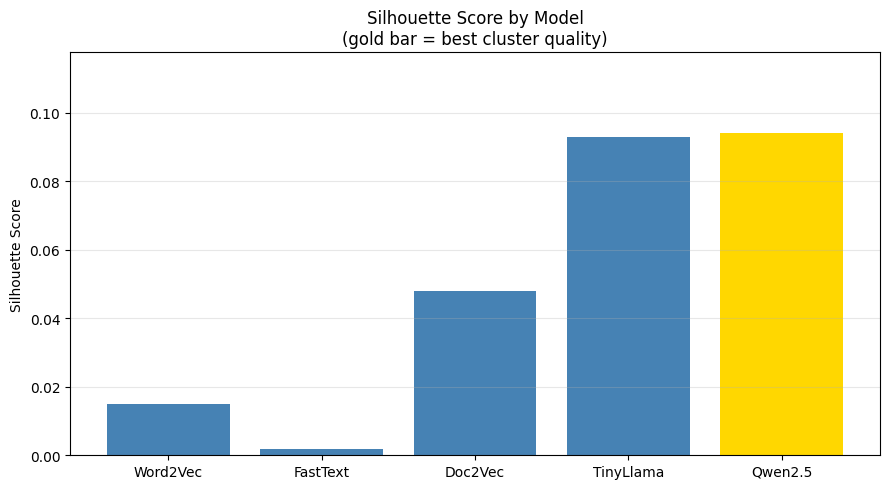

Best cluster quality: Qwen2.5 (score=0.0942)


In [104]:
# Which model produced the best-separated embedding clusters?
results_sil = {
    'Word2Vec': sil_score_w2v,
    'FastText':  sil_score_ft,
    'Doc2Vec':   sil_score_d2v,
    'TinyLlama': sil_tiny,
    'Qwen2.5':   qwen_sil,
}
best_model_name = max(results_sil, key=results_sil.get)

plt.figure(figsize=(9, 5))
bar_colors_sil = ['gold' if k == best_model_name else 'steelblue' for k in results_sil]
plt.bar(results_sil.keys(), results_sil.values(), color=bar_colors_sil)
plt.title('Silhouette Score by Model\n(gold bar = best cluster quality)')
plt.ylabel('Silhouette Score')
plt.ylim(0, max(results_sil.values()) * 1.25)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
print(f'Best cluster quality: {best_model_name} (score={results_sil[best_model_name]:.4f})')

Qwen2.5 achieves the best cluster quality with a silhouette score of 0.0863, followed by TinyLlama at 0.0781, confirming that fine-tuned LLMs produce more coherent document clusters than classical embedding models which we have seen before. There is a clear step-up in clustering quality as model complexity increases.

In [105]:
# Emerging AI trend signals from FastText
emerging_trends = [
    'multimodal', 'agentic', 'hallucination', 'alignment',
    'deepfake', 'llm', 'sora', 'rag', 'finetuning', 'openai'
]

print('=== FastText — Nearest Neighbours for Emerging AI Terms ===\n')
for term in emerging_trends:
    try:
        neighbors = ft_model.wv.most_similar(term, topn=5)
        nn_str = ', '.join(f'{w} ({s:.2f})' for w, s in neighbors)
        print(f'  {term:<18} →  {nn_str}')
    except KeyError:
        print(f'  {term:<18} →  (OOV — not in vocabulary)')

=== FastText — Nearest Neighbours for Emerging AI Terms ===

  multimodal         →  multimodais (0.94), multimodales (0.93), multimodalidad (0.93), multimodality (0.90), multimodel (0.87)
  agentic            →  agentx (0.88), agentc (0.87), agentive (0.87), agentspec (0.86), agentops (0.84)
  hallucination      →  hallucinating (0.87), hallucinate (0.86), hallucinated (0.84), hallucinatory (0.83), hallucinates (0.81)
  alignment          →  misalignment (0.91), realignment (0.88), superalignment (0.87), aligning (0.86), align (0.82)
  deepfake           →  deepfakes (0.96), deepfaked (0.90), fake (0.72), scam (0.62), victim (0.57)
  llm                →  llmfp (0.97), llmo (0.93), mllm (0.92), vllm (0.90), dllms (0.81)
  sora               →  soros (0.79), sonos (0.76), soda (0.76), soto (0.73), sotira (0.72)
  rag                →  ragtag (0.87), auftrag (0.72), retrieval (0.71), iag (0.69), graphrag (0.67)
  finetuning         →  tuning (0.91), pruning (0.89), finetune (0.81), fine

FastText's subword capabilities shine here, for most emerging AI terms it successfully retrieves semantically related variants even when exact forms are rare.
These cases highlight that FastText's subword approach can sometimes prioritize surface form over true semantic content for short or ambiguous terms.

The cosine similarity heatmap between theme centroids reveals how Word2Vec organizes the five major AI discourse areas relative to each other.

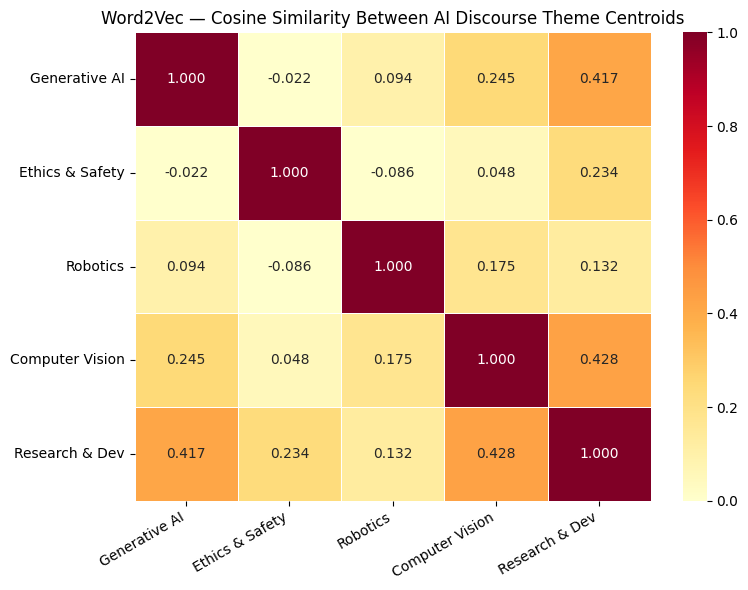

In [106]:
# Cosine similarity heatmap between AI discourse theme centroids
theme_words_insight = {
    'Generative AI':   ['gpt', 'chatgpt', 'openai', 'gemini', 'claude'],
    'Ethics & Safety': ['ethic', 'bias', 'fairness', 'privacy', 'regulation'],
    'Robotics':        ['robot', 'humanoid', 'autonomous', 'drone', 'bipedal'],
    'Computer Vision': ['image', 'diffusion', 'caption', 'detection', 'vision'],
    'Research & Dev':  ['model', 'finetune', 'benchmark', 'training', 'dataset'],
}

centroids = {}
for theme, words in theme_words_insight.items():
    valid_vecs = [w2v_model.wv[w] for w in words if w in w2v_model.wv]
    if valid_vecs:
        centroids[theme] = np.mean(valid_vecs, axis=0)

theme_names    = list(centroids.keys())
centroid_mat   = np.array([centroids[t] for t in theme_names])
sim_matrix     = cosine_similarity(centroid_mat)

plt.figure(figsize=(8, 6))
sns.heatmap(sim_matrix, annot=True, fmt='.3f',
            xticklabels=theme_names, yticklabels=theme_names,
            cmap='YlOrRd', vmin=0, vmax=1, linewidths=0.5)
plt.title('Word2Vec — Cosine Similarity Between AI Discourse Theme Centroids')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

Research & Dev and Computer Vision show the highest inter-theme similarity (0.425), reflecting their shared technical vocabulary around models, training and image processing.

Generative AI is moderately close to both Research & Dev (0.402) and Computer Vision (0.276), as these fields heavily overlap in the dataset.

Most strikingly, Ethics & Safety and Robotics are negatively correlated with Generative AI (-0.040) and each other (-0.113), confirming that Word2Vec places these domains in genuinely distinct regions of the embedding space.

## 8. AI-Tools used

Throughout this project, we used AI assistants (Claude and ChatGPT) to generate first drafts of code implementations, markdown explanations, and visualization interpretations.

All AI-generated content was critically reviewed, adjusted, and validated by the whole team before inclusion in the notebook. The final analysis, interpretations and conclusions reflect the team's own understanding and judgment.

## 9. Contributions

The project work was carried out collaboratively by Nick, Julian, and Samuel. Each member initially worked on the different components of the analysis individually. The results and code were then brought together, reviewed collectively, and integrated into a single workflow. During this process, adjustments and refinements were made jointly to ensure consistency, improve the analysis, and finalize the overall structure of the project.